# Resting Batch Face 

### Från 😐 till 😡 med Convolutional Neural Networks

----

I detta projekt utforskas och utvärderas olika strategier och optimeringstaktiker för att förbättra prestandan hos CNN-modeller vid klassificering av ansiktsuttryck baserat på FER-2013 datasetet.

Notebooken går igenom hela processen från dataanalys och förbehandling till modellträning, utvärdering och prediktioner på ny data, samt en analys och reflektion kring modellernas olika resultat.

In [2]:
# --- SETUP & IMPORTS ---

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

from pathlib import Path

from PIL import Image

import random

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers, optimizers
from keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

## 1. Dataanalys

### 1.1 Antal bilder

#### Total, Train & Test

Jag börjar med att räkna hur många bilder det finns i mapparna train och test. 

Det gör jag med en funktion som räknar antalet filer som slutar på .jgp, .jpeg eller .png i en given mapp. 

Jag använder mig av Path från pathlib som är det enklare och mer moderna sättet att hantera sökvägar jämfört med os.path då pathlib hanterar sökvägarna som objekt istället för vanliga strängar. 

Path-objekt kommer med en metod rglob() vilket gör det möjligt att leta vidare i undermappar. 

rglob() returnerar en så kallad generator, vilket bara "går förbi" filerna i mapparna och lägger inte dem på minnet. 

list() behövs då för att generatorn ska faktiskt ska samla på sig alla bilder så att det sen går att räkna dem med len().

https://docs.python.org/3/library/pathlib.html

https://www.geeksforgeeks.org/python/pathlib-module-in-python/ 

In [3]:
def count_images(path):
    """
    Funktion för att räkna antalet filer som slutar på .jpg, .jpeg eller .png i en given mapp.

    path (Path):
        En pathlib.Path-sökväg till mappen som ska "skannas"

    Returnerar totalt antal bilder hittade i mappen (och dess undermappar) (int)
    """
    return len(list(path.rglob("*.jpg"))) + len(list(path.rglob("*jpeg"))) + len(list(path.rglob("*.png")))     
    # list() behövs då rglob() är en generator som annars inte lägger bilderna på minnet 

# Skapar sökväg till huvudmappen
data_dir = Path("data")

# Räknar antalet bilder i mapparna data, train och test
train_count = count_images(data_dir / "train")
test_count = count_images(data_dir / "test")
total_count = train_count + test_count

# Räknar ut andel 
train_percent = (train_count / total_count) * 100
test_percent = (test_count / total_count) * 100
total_percent = train_percent + test_percent

# Skapar data till statestik-tabell
stats_images = {
    "Set": ["Train", "Test", "Total"],
    "Antal bilder": [train_count, test_count, total_count],
    "Andel": [f"{train_percent:.1f}%", f"{test_percent:.1f}%", f"{total_percent:.1f}%"]
}

# Skapar en tabell för att kunna presentera resultatet snyggare
df_stats_images = pd.DataFrame(stats_images)

df_stats_images

,Set,Antal bilder,Andel
0,Train,28691,80.0%
1,Test,7178,20.0%
2,Total,35869,100.0%


#### Klasserna

När jag vet hur många bilder det finns i train resp. test vill jag veta hur många bilder det finns per klass. 

Varje klass har sin egen mapp i train eller test. 

Jag skapar därför en funktion som sammanställer statistiken (antalet bilder) och returnerar resultatet i en fin DataFrame. 

Funktionen använder den tidigare funktionen count_images för att räkna bilderna i varje undermapp som hör till huvudmappen. 

Den räknar ut andel, hämtar klassnamnet från mappens namn och sparar all information som en dictionary och lägger det i en lista. 

Funktionen dubbelkollar också om det finns filer som ligger utanför dessa klassmappar. Detta för att jag vill se hur städad datan är. 

In [4]:
def get_class_dataframe(folder_path, total_set_count):
    """
    Skapar en DataFrame med statistik för alla klasser (undermappar).

    folder_path:
        Sökvägen till mappen.
    
    total_set_count:
        Totala antalet bilder i den mappen (för att räkna ut andel).

    Returnerar en pd.DataFrame
    """

    # Skapar två listor. Den ena för att spara informationen som är intressant.
    # Den andra för att lägga lösa filer.
    stats_list = []
    stray_files_found = []

    # Loop för att gå igenom varje undermapp och ta ut statistik för den (= antalet bilder)
    for class_path in sorted(folder_path.iterdir()):        
        if class_path.is_dir():
            count = count_images(class_path)
            percent = (count / total_set_count) * 100

            # Klassinformationen sparas som en dictionary i listan för att det ska gå enkelt att skapa en DataFrame sen
            stats_list.append({
                "Klass": class_path.name,
                "Antal": count,
                "Andel": f"{percent:.1f}%"
            })
        else:
            stray_files_found.append(class_path.name)

    # Kontrollerar om det finns eller inte finns lösa filer utanför mapparna 
    # (En liten check för att se hur städad datan är)
    if stray_files_found:
        print(f"Meddelande för '{folder_path.name}': Det finns filer utanför mapparna.")
    else:
        print(f"Meddelande för '{folder_path.name}': Det finns inga filer utanför mapparna.")

    # Returnerar en DataFrame för att resultatet ska gå att presentera snyggt 
    return pd.DataFrame(stats_list)

In [5]:
# Skriver ut statistik-tabellen för "train"
df_train = get_class_dataframe(data_dir / "train", train_count)

df_train

Meddelande för 'train': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,3977,13.9%
1,disgust,436,1.5%
2,fear,4097,14.3%
3,happy,7215,25.1%
4,neutral,4965,17.3%
5,sad,4830,16.8%
6,surprise,3171,11.1%


In [6]:
# Skriver ut statistik-tabellen för "test"
df_test = get_class_dataframe(data_dir / "test", test_count)

df_test

Meddelande för 'test': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,958,13.3%
1,disgust,111,1.5%
2,fear,1024,14.3%
3,happy,1774,24.7%
4,neutral,1233,17.2%
5,sad,1247,17.4%
6,surprise,831,11.6%


#### Slutsats kontroll av antalet bilder

- FER-2013 är vid nedladdning redan uppdelat i tränings- och testdata med en fördelning på 80 % träningsdata och 20 % testdata.
- Det finns en obalans mellan klasserna i "train" där träningsdatan till 25% består av "happy" men bara till 1,5% av "disgust". Övriga klasser är fördelade någorlunda jämnt inom spannet 11-17%.
- Den obalans som råder i "train" ser likadan ut i "test". 
- Jag ser nu (2026-05-26) att jag saknar några träningsbilder. Av någon anledning så har jag 28 691 träningsbilder istället för 28 709. Så jag har ju gjort något knasigt. Men eftersom det enligt instruktionerna var tillåtet att bara använda delar av datan väljer jag att ignorera detta fel...


### 1.2 Bildformat

För att fortsätta få en uppfattning av hur städat datasetet är går jag vidare med att undersöka om alla bilder är lika stora, har samma format och samma färgskala.

Detta gör jag genom att loopa igenom alla filer i alla mappar och sparar sådan information som är unik. 

In [7]:
# Skapar tomma "behållare" som är som listor, men som inte kan innehålla dubletter. 
all_sizes = set()       # Här sparas bildstorlekar
all_formats = set()     # Här sparas bildformat
all_modes = set()       # Här sparas färgskala

# Går igenom ALLA bilder för att plocka ut alla olika typer av bildstorlekar, bildformat och färgskala. 
for img_path in data_dir.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:    # Säkerställer att koden bara försöker bearbeta filer som faktiskt är bilder
        with Image.open(img_path) as img:                       # Öppnar varje bild och plockar ut efterfrågad information. Stänger sedan bilden. 
            all_sizes.add(img.size)
            all_formats.add(img.format)
            all_modes.add(img.mode)

https://docs.python.org/3/tutorial/datastructures.html#sets 

https://pillow.readthedocs.io/en/stable/reference/Image.html

https://pillow.readthedocs.io/en/stable/reference/open_files.html#file-handling

In [8]:
# Skriver ut resultatet från kodcellen innan
print(f"Unika storlekar: {all_sizes}")
print(f"Unika format: {all_formats}")
print(f"Unika modes: {all_modes}")

Unika storlekar: {(48, 48)}
Unika format: {'JPEG'}
Unika modes: {'L'}


#### Slutsats bildformat

Alla bilder har samma storlek (48 x 48), samma format (jpg) och är i gråskala (L) (motsvarande för färg är RGB).

### 1.3 Visuell kontroll

Nästa naturliga steg är att skriva ut några bilder från varje klass för att se vad jag har att jobba med. 

Jag väljer att plotta 5 bilder från varje klass i ett rutnät. Jag väljer att skriva ut flera bilder för att öka mina chanser att upptäcka brus.

In [9]:
random.seed(42)

n_samples = 5                         
train_path = data_dir / "train"     

# Hittar alla unika klasser genom att lista mapparna och ignorera sådant som inte är en mapp
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])

# Skapar ett rutnät för bilderna där varje klass får en egen rad
# och anpassar storleken på figuren dynamiskt efter antalet bilder och klasser
preview_fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))

# Loopar igenom varje klassmapp och plockar ut 5 slumpmässiga bilder
for i, label in enumerate(classes):
    class_dir = train_path / label
    samples = random.sample(list(class_dir.glob("*.jpg")), n_samples)

    # Loopar igenom varje slumpmässigt vald bild
    # och plottar dem i turordning på klassraden
    for j, img_path in enumerate(samples):
        with Image.open(img_path) as img:
            ax = axes[i, j]
            ax.imshow(img, cmap="grey")
            ax.axis("off")

            # Skriver ut klassnamnet som rubrik på den första bilden i varje rad
            if j == 0:                                                  
                ax.set_title(label, loc="left", fontweight="bold")

plt.tight_layout()

plt.close(preview_fig)

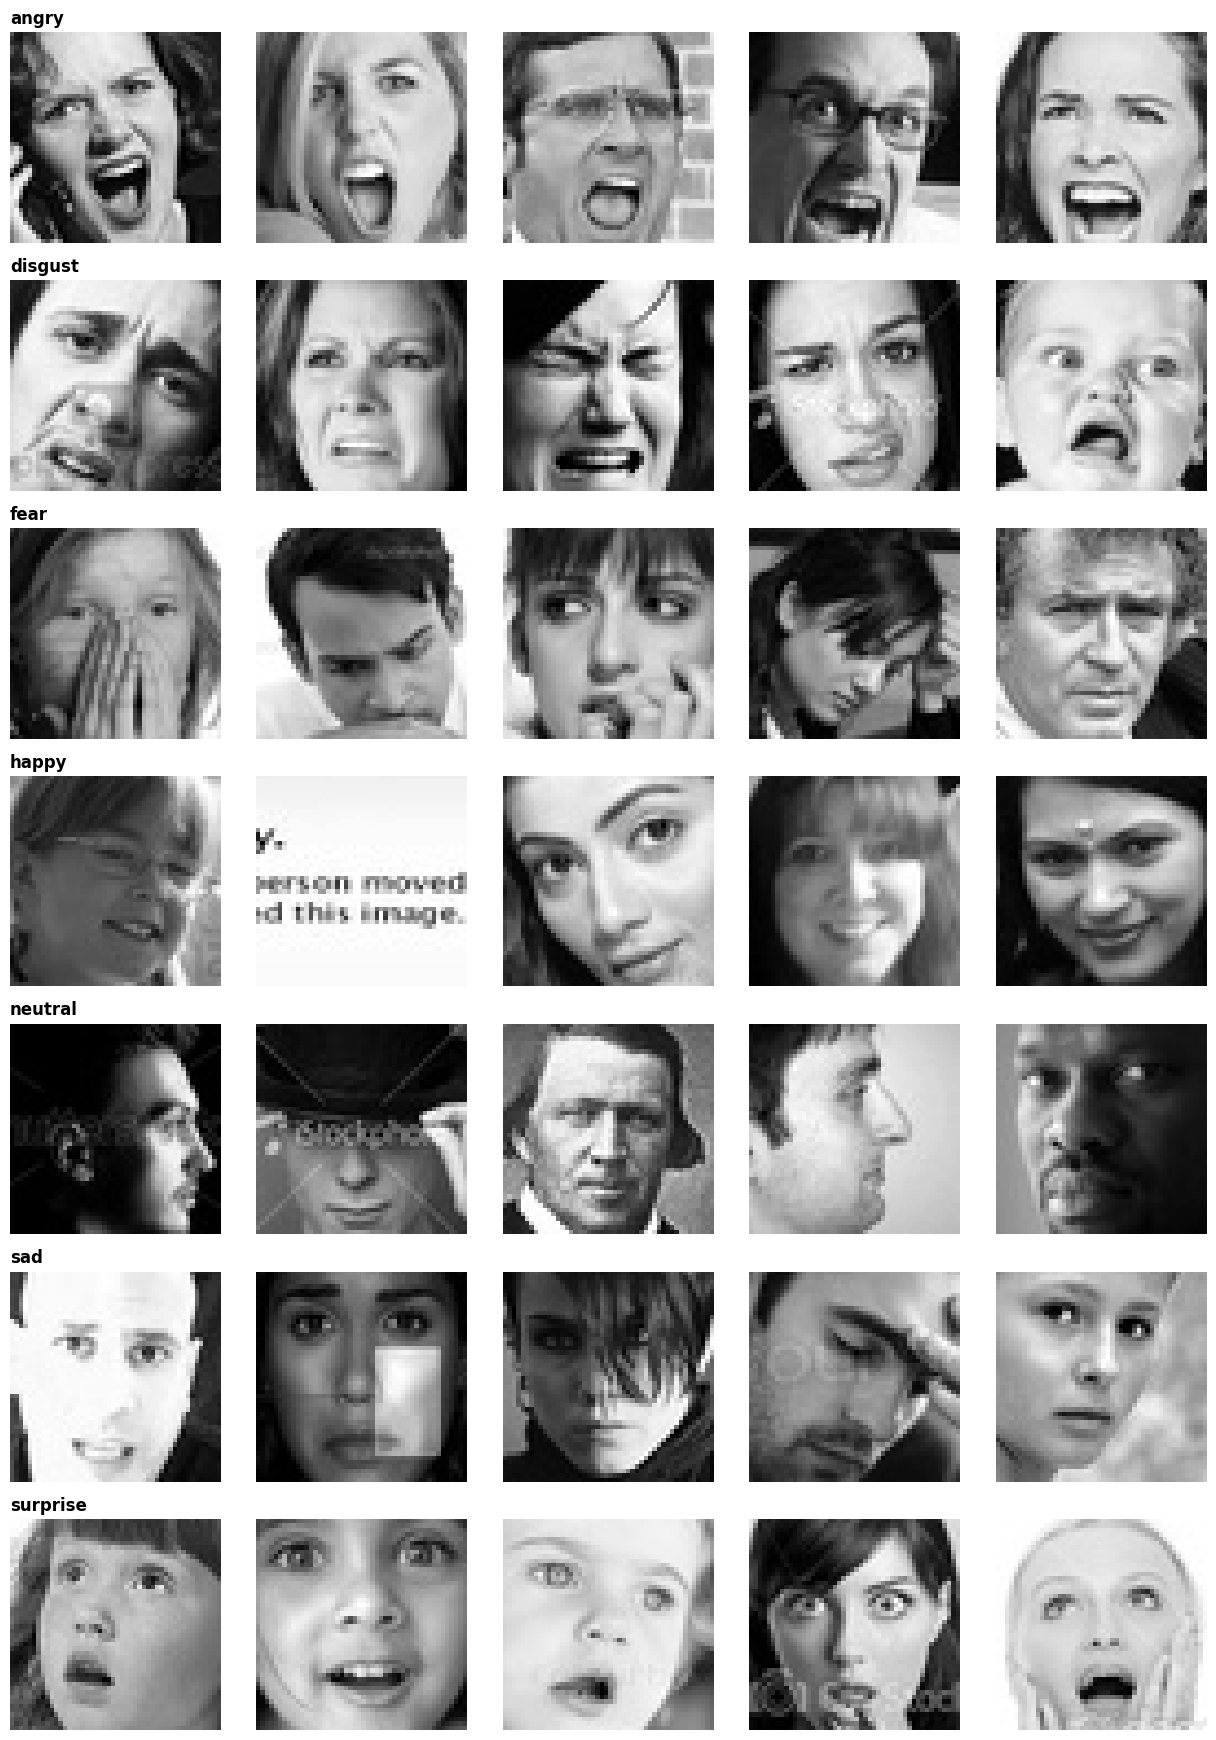

In [10]:
preview_fig

#### Slutsats visuell kontroll

https://arxiv.org/pdf/1307.0414 (rapport om tävlingen som fick FER-2013 att uppstå)

FER-2013 togs fram i samband med en maskininlärningstävling 2013. Datasetet skapades genom att använda Google Image Search API med 184 känslorelaterade sökord, som sedan kategeoriserades i sju känsloklasser: 

- angry
- disgust
- fear
- happy
- sad
- surpries 
- neutral

Jag vill säga att detta i kombination med att tolkning av känslouttryck är subjektivt gör FER-2013 till ett svårt dataset för min NN-modell att sätta tänderna i... 

Bara i dessa 35 slumpmässiga bilder finns det brus som gör det svårt: 

- flera bilder innehåller text
- en bild finns inte
- varje rad innehåller minst en bild som mycket väl skulle kunna passa i en eller flera andra klasser  

## 2. Förbehandling

### 2.1 Dela upp datan i train och val

Datan delas upp i 80 % träningsdata och 20 % valideringsdata. Detta följer etablerad standardpraxis inom Machine Learning för att säkerställa att modellen har tillräckligt med exempel att lära sig av samtidigt som valideringsmängden är stor nog för att ge en statistiskt pålitlig indikation på generaliseringsförmåga. 

Jag har även bestämt mig för att göra både en modell som bara får träna på två klasser och en modell som får träna på alla sju så jag behöver skapa två olika dataset:

1) Två klasser
2) Alla sju klasser

Jag väljer två klasser som är mycket olika: happy och sad. 

För att göra jämförelsen mellan den binära modellen och en modell som tränas på alla sju klasser mer rättvis ser jag till att klasserna happy och sad är lika stora varandra och är lika stora i båda dataseten. Jag vill inte ta bort för mycket data och väljer därför totalt 3000 bilder per klass. Jag behöver dessutom se till att det är exakt samma happy- och sad-bilder i båda dataseten. Detta för att jämförelsen ska bli så korrekt som möjligt. 

Datan behöver också, utöver uppdelningen i train och val, gå från bildfiler i mappar till användbara X och y.

In [11]:
def create_image_df(directory_path, class_list):
    """
    Skapar en DataFrame som fungerar som en indexfil över bilddatasetet.

    Funktionen skannar mapparna för varje klass och sparar bara bildens
    sökväg och etikett. På så vis behöver inte alla bilder läsas in i 
    minnet direkt, utan de kan läsas in senare när datan delas upp i 
    X och y eller när bilderna behövs för träning/validering.

    directory_path: sökvägen till huvudmappen (t.ex. data/train)
    class_list: en lista med strängar för de klasser som ska skannas.
    """
    all_data = []
    for cls in class_list:
        cls_dir = directory_path / cls
        if cls_dir.is_dir():
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                    all_data.append({
                        "path": img_path,
                        "label": cls
                    })
    
    return pd.DataFrame(all_data)

In [12]:
# Inställningarna för datamapp och tillgängliga klasser
base_dir = Path("data/train")
classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# Skannar mapparna och bygger en övergripande indexfil med alla bildsökvägar
df = create_image_df(base_dir, classes)

In [13]:
# Sampling av 3000 bilder från varje klass
# Om en klass har färre än 3000 bilder behålls alla
sampled_dfs = []
for cls in classes:
    cls_df = df[df["label"] == cls]         # cls_df blir som en minitabell som bara innehåller bilderna från den klassen som loopen bearbetar
    if len(cls_df) >= 3000:
        cls_sampled = cls_df.sample(n=3000, random_state=42)
    else:
        cls_sampled = cls_df
    sampled_dfs.append(cls_sampled)

# Slår ihop alla klasserna till en gemensam DataFrame och återställer indexet
main_df = pd.concat(sampled_dfs).reset_index(drop=True)

# Delar upp den gemensamma huvudtabellen i träning- och valideringsdata
train_df_all, val_df_all = train_test_split(
    main_df,
    test_size=0.2,
    stratify=main_df["label"],              # Behåller samma klassbalans eftersom klassen disgust innehåller så få bilder
    random_state=42
)

# Filtrerar ut happy och sad från den totala tränings- och valideringsdatan 
# Detta görs efter uppdelningen i train och val för att 
# 1) det ska bli exakt samma happy- och sad-bilder i det binära datasetet och det fullständiga datasetet
# 2) undvika att samma bild hamnar i val i det ena datasetet och i train i det andra
binary_classes = ["happy", "sad"]
train_df_binary = train_df_all[train_df_all["label"].isin(binary_classes)]
val_df_binary = val_df_all[val_df_all["label"].isin(binary_classes)]

In [14]:
# Kontroll vad train_df_innehåller 
# och att bilderna är blandade
# print(train_df_all[:10])

In [15]:
def load_images_from_df(df, label_mapping):
    """
    Läser in bildfiler baserat på en DataFrame och konverterar dem till Numpy-arrays.

    Funktionen transformerar datan till det format som TensorFlow/Keras kräver. 
    Den loopar igenom tabellen, läser in varje bild via OpenCV, konverterar den till
    gråskala (eftersom OpenCV annars automatiskt läser in bilder som färg, vilket är
    onödigt och drar mer minne) och mappar textetiketter till heltal. 

    En inbyggd felhantering säkerställer att eventuella korrupta eller saknade 
    bildfiler hoppas över så att koden inte kraschar. 

    df: Tabell som innehåller kolumnerna "path" (sökväg till bild) och "label"
        (textsträng för klassen, t.ex. "angry")
    label_mapping: En dictionary som mappar textetiketter till numeriska index.
    """
    X = []
    y = []

    for _, row in df.iterrows():
        img_path_str = str(row["path"])
        img = cv2.imread(img_path_str, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            X.append(img)
            y.append(label_mapping[row["label"]])

    return np.array(X), np.array(y)

In [16]:
# Skapar mappning-dictionaries, en för det fullständiga datasetet
# och en för det binära
multiclass_mapping = {cls: idx for idx, cls in enumerate(classes)}
binary_mapping = {"happy": 0, "sad": 1}

In [17]:
# Skapar dataseten, uppdelade i X och y
# m1, "modell 1", det binära
# m2, "modell 2", det fullständiga
X_train_m1, y_train_m1 = load_images_from_df(train_df_binary, binary_mapping)
X_val_m1, y_val_m1 = load_images_from_df(val_df_binary, binary_mapping)

X_train_m2, y_train_m2 = load_images_from_df(train_df_all, multiclass_mapping)
X_val_m2, y_val_m2 = load_images_from_df(val_df_all, multiclass_mapping)

In [18]:
# Kontrollerar shape
print("MODELL 1 (Binär: Happy & Sad)")
print(f"X_train_m1 shape: {X_train_m1.shape}  (Förväntat: (4800, 48, 48))")
print(f"X_val_m1   shape: {X_val_m1.shape}   (Förväntat: (1200, 48, 48))")

print("\nMODELL 2 (Multiclass: Alla 7)")
print(f"X_train_m2 shape: {X_train_m2.shape} (Förväntat: runt (14748, 48, 48))")
print(f"X_val_m2   shape: {X_val_m2.shape}  (Förväntat: runt (3688, 48, 48))")

MODELL 1 (Binär: Happy & Sad)
X_train_m1 shape: (4800, 48, 48)  (Förväntat: (4800, 48, 48))
X_val_m1   shape: (1200, 48, 48)   (Förväntat: (1200, 48, 48))

MODELL 2 (Multiclass: Alla 7)
X_train_m2 shape: (14748, 48, 48) (Förväntat: runt (14748, 48, 48))
X_val_m2   shape: (3688, 48, 48)  (Förväntat: runt (3688, 48, 48))


In [19]:
# Kontrollerar klassfördelningen
print("Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):")
# Index 0 = happy, Index 1 = sad
print(f"Happy: {np.bincount(y_train_m1)[0]}, Sad: {np.bincount(y_train_m1)[1]}")

print("\nModell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):")
print(f"Happy: {np.bincount(y_val_m1)[0]}, Sad: {np.bincount(y_val_m1)[1]}")

print("\nModell 2 - Fördelning per klass i träningsdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_train_m2)[idx]} bilder")

print("\nModell 2 - Fördelning per klass i valideringssdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_val_m2)[idx]} bilder")

Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):
Happy: 2400, Sad: 2400

Modell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):
Happy: 600, Sad: 600

Modell 2 - Fördelning per klass i träningsdatan:
Klass 0 (angry): 2400 bilder
Klass 1 (disgust): 348 bilder
Klass 2 (fear): 2400 bilder
Klass 3 (happy): 2400 bilder
Klass 4 (neutral): 2400 bilder
Klass 5 (sad): 2400 bilder
Klass 6 (surprise): 2400 bilder

Modell 2 - Fördelning per klass i valideringssdatan:
Klass 0 (angry): 600 bilder
Klass 1 (disgust): 88 bilder
Klass 2 (fear): 600 bilder
Klass 3 (happy): 600 bilder
Klass 4 (neutral): 600 bilder
Klass 5 (sad): 600 bilder
Klass 6 (surprise): 600 bilder


När jag har kontrollerat att antalet bilder blev rätt vill jag också kontrollera att bilderna ser ut att stämma.

Jag väljer att skriva ut den första bilden i varje klass från träningsdatan. 

Eftersom jag behöver plotta bilder två gånger lägger jag in koden för det i en funktion.

In [20]:
def find_indices_per_class(y_array, num_classes):
    """
    Hittar indexet för den allra första bilden i varje klass. 

    Funktionen letar igenom den shufflade listan med facit-siffror
    (y_array) och sparar platsen (indexet) där en klass dyker upp 
    första gången. Detta index användes sedan av plot-funktionen
    för att hämta rätt bild.

    y_array:            en 1D-array som innehåller alla bilders
                        rätta sifferetiketter 
    num_classes:        antalet unika klasser i datasetet

    Returnerar en dictionary där nyckeln är klassens siffra och 
    värdet är indexet till den första bilden i den klassen.
    """
    indices_per_class = {}
    for label_siffra in range(num_classes):
        all_indices = np.where(y_array == label_siffra)[0]
        if len(all_indices) > 0:
            indices_per_class[label_siffra] = all_indices[0]
    return indices_per_class

# Skapar inversa mappningar ("vänder" på "ordböckerna", dvs går från siffra till text)
inverse_binary_mapping = {v: k for k, v in binary_mapping.items()}
inverse_multiclass_mapping = {v: k for k, v in multiclass_mapping.items()}

# Skapar funktion för att plotta bilder i ett rutnät
def plot_images_grid(X_array, indices_dict, inverse_mapping, title, num_classes):
    """
    Plottar en bild från varje klass i ett rutnät.

    1. Funktionen tar emot "indices_dict" (som skapas av find_indices_per_class)
    för att veta exakt vilket index den första bilden i varje klass har.
    2. Den hämtar rätt bild ur "X_array" med hjälp av dessa index. 
    3. Den använder "inverse_mapping" för att översätta klassens sifferetikett
    tillbaka till text så att varje bild får en begriplig rubrik.
    4. Den räknar dynamiskt ut hur många rader och kolumner som behövs och 
    gömmer tomma rutor

    X_array:            matrisen med alla bilders pixeldata
    indices_dict:       dictionary med klass-siffror som nycklar och bildens 
                        index som värde
    inverse_mapping:    dictionary för att översätta siffra till textnamn
    title:              rubrik för hela figuren
    num_classes:        antalet klasser som ska visas (2 eller 7)
    """
    cols = 2 if num_classes == 2 else 4
    rows = (num_classes + cols - 1) // cols 

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(title, fontsize=16)
    
    # Gör att alla bildrutor hamnar i en lång rad, istället för två rader
    # så det blir enklare att köra loopen
    axes_flat = axes.flatten() if num_classes > 1 else [axes]

    for label_siffra, idx in indices_dict.items():
        if label_siffra < len(axes_flat):
            ax = axes_flat[label_siffra]
            ax.imshow(X_array[idx], cmap="gray")
            
            label_text = inverse_mapping[label_siffra]
            ax.set_title(f"{label_text} ({label_siffra})", fontsize=12)
            ax.axis("off")
            
    for i in range(len(indices_dict), len(axes_flat)):
        axes_flat[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])          # Skapar plats åt huvudrubriken så den inte krockar med något
    plt.show()

Kontroll av Modell 1 (Happy & Sad)


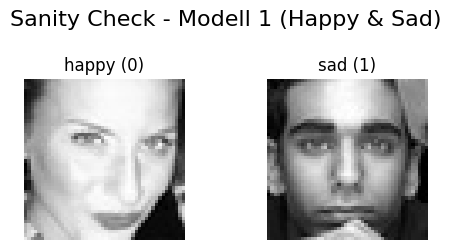

In [21]:
# Hämtar index för första bilden i varje klass
# och plottar rutnätet för det binära datasetet
print("Kontroll av Modell 1 (Happy & Sad)")
indices_m1 = find_indices_per_class(y_train_m1, num_classes=2)

plot_images_grid(
    X_train_m1, 
    indices_m1, 
    inverse_binary_mapping, 
    "Sanity Check - Modell 1 (Happy & Sad)",
    num_classes=2
)

Kontroll av Modell 2 (Alla 7 Klasser)


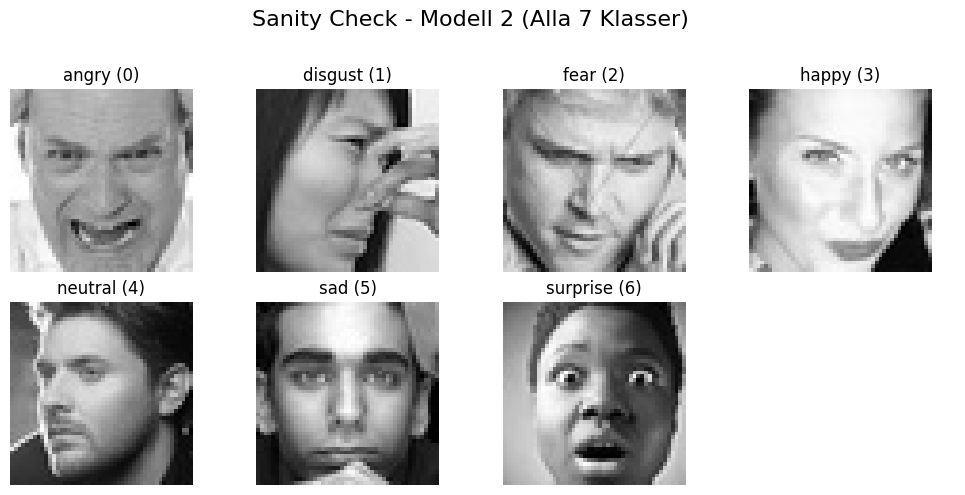

In [22]:
# Hämtar index för första bilden i varje klass
# och plottar rutnätet för det fullständiga datasetet
print("Kontroll av Modell 2 (Alla 7 Klasser)")
num_all_classes = len(classes)
indices_m2 = find_indices_per_class(y_train_m2, num_classes=num_all_classes)

plot_images_grid(
    X_train_m2, 
    indices_m2, 
    inverse_multiclass_mapping, 
    "Sanity Check - Modell 2 (Alla 7 Klasser)",
    num_classes=num_all_classes
)

Utifrån de bilder som plottas, både ur det binära datasetet och ur det fullständiga, så tycker jag det ser ut som allt fungerar som det var tänkt. 

Det är samma happy- och sad-bild för båda dataseten. 

Alla bilder från det fullständiga datasetet ser ut att ligga i korrekt klass, även om jag tycker att mannen på bilden för "fear" mer ser sugen ut än rädd. 

Men det säger väl mer om mig än något annat...

### 2.2 Testdatan

Testdatan förbereds här på samma sätt som tränings- och valideringsdatan.

Jag skapar en komplett tabell för alla sju klasser och en filtrerad variant för den binära.

Filerna läses sedan in i Numpy-arrays (X och y) med hjälp av funktionen load_images_from_df.

Jag gör ingen visuell kontroll av bilderna i testdatan. Detta för att hålla testdatan dold så jag inte åker på undermedveten bias.

In [23]:
base_test_dir = Path("data/test")

test_df_all = create_image_df(base_test_dir, classes)

test_df_binary = test_df_all[test_df_all["label"].isin(binary_classes)]

In [24]:
X_test_m1, y_test_m1 = load_images_from_df(test_df_binary, binary_mapping)

X_test_m2, y_test_m2 = load_images_from_df(test_df_all, multiclass_mapping)

In [25]:
print("VERIFIERING AV TESTDATA")
print(f"Modell 1 (Happy/Sad) - X_test: {X_test_m1.shape}, y_test: {y_test_m1.shape}")
print(f"Modell 2 (Alla 7)    - X_test: {X_test_m2.shape}, y_test: {y_test_m2.shape}")

VERIFIERING AV TESTDATA
Modell 1 (Happy/Sad) - X_test: (3021, 48, 48), y_test: (3021,)
Modell 2 (Alla 7)    - X_test: (7178, 48, 48), y_test: (7178,)


### 2.3 Skala datan

De sista stegen i dataförberedelsen är att skala bilderna samt att lägga till en kanaldimension.

Bildernas pixelvärde ligger från början mellan 0 och 255. 

Genom att dividera värdena med 255 normaliseras datan till intervallet 0-1 vilket ofta gör träningen mer stabil och effektiv för neurala nätverk.

CNN-lager förväntar sig bilder i formatet (höjd, bredd, kanaler) så jag behöver lägga till en extra dimension för färgkanalen. 

Bilderna får då formen (48, 48, 1) där 1 betyder färgkanal (1 = gråskala, 3 = RGB/färgbild). 

In [26]:
# Skala bilderna till 0-1
X_train_m1_scaled = X_train_m1 / 255.0
X_val_m1_scaled = X_val_m1 / 255.0
X_test_m1_scaled = X_test_m1 / 255.0

# Lägg till färgkanalen längst bak (axis=-1)
X_train_m1_scaled = np.expand_dims(X_train_m1_scaled, axis=-1)
X_val_m1_scaled = np.expand_dims(X_val_m1_scaled, axis=-1)
X_test_m1_scaled = np.expand_dims(X_test_m1_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 1 klar för träning! Form: {X_train_m1_scaled.shape}")
# Ska visa: (4800, 48, 48, 1)

Data till modell 1 klar för träning! Form: (4800, 48, 48, 1)


In [27]:
# Skala bilderna till 0-1
X_train_m2_scaled = X_train_m2 / 255.0
X_val_m2_scaled = X_val_m2 / 255.0
X_test_m2_scaled = X_test_m2 / 255.0

# Lägg till färgkanalen längst bak
X_train_m2_scaled = np.expand_dims(X_train_m2_scaled, axis=-1)
X_val_m2_scaled = np.expand_dims(X_val_m2_scaled, axis=-1)
X_test_m2_scaled = np.expand_dims(X_test_m2_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 2+ klar för träning! Form: {X_train_m2_scaled.shape}")
# Ska visa: (runt 14748, 48, 48, 1)

Data till modell 2+ klar för träning! Form: (14748, 48, 48, 1)


## 3. Modellering och experiment

Nu börjar äntligen det roliga!

I det här avsnittet undersöks två övergripande frågeställningar inom bildklassificering med CNN-modeller. Fokus ligger inte primärt på finjustering av hyperparametrar utan på att analysera hur olika träningsstrategier påverkar modellens prestanda. 

Det första experimentet undersöker om en modell kan dra nytta av att initialiserar från en tidigare tränad modell med begränsat antal klasser. Först tränas en CNN-modell enbart på klasserna happy och sad. Syftet är dels att analysera hur väl modellen presterar på en förenklad tvåklassuppgift, dels att använda den som grund för ett vidare experiment inspirerat av transfer learning. Därefter skapas en andra modell som initialiseras med vikter från den första modellen, men tränas vidare på samtliga klasser i datasetet. Denna modell jämförs sedan med en tredje modell med identisk arktiektur som istället tränas från slumpmässigt initialiserade vikter. På så sätt kan effekten av den tidigare tvåklass-träningen analyseras. 

Det andra experimentet foskuerar på hantering av klassobalans i datasetet. Först tas en baseline-modell fram genom att testa och utvärdera mindre arkitektoniska förbättringar, exempelvis fler CNN-lager och BatchNormalization. När en stabil baseline har etablerats används denna som utgångspunkt för två separata metoder att hantera obalansen mellan klasserna. I den första modellen används class_weight="balanced" under träningen, mendan den andra modellen istället använder offline data augumentation för att öka mängden träningsdata i den underrepresenterade klassen (disgust). 

För att möjliggöra rättvisa jämförelser hålls stora delar av träningsupplägget konstant mellan modellerna. Samma batch size och optimerare används genomgående, medan learning rate och antal epoker i huvudsak håll lika mellan experienten och endast justeras när ett specifikt experiments upplägg kräver det. 

### Hjälpfunktioner

Eftersom experimentdelen består av flera modeller som tränas, utvärderas och jämförs på liknande sätt användes ett antal hjälpfunktioner.

Syftet med dessa är att minska upprepning i koden och göra experimenten mer konsekventa. Funktionerna används bland annat för att kompliera modeller, träna dem med samma grundinställningar, visualisera träningshistorik samt utvärdera modellernas resultat per klass.

In [28]:
def compile_model(model, lr=0.001):
    """
    Kompilerar en modell med optimerare, loss och metric. 

    Funktionen förbereder modellen för träning. Den använder Adam 
    som optimerare med ställbar learning rate. 
    Eftersom klassetiketterna är sparade som heltal används
    sparse_categorical_crossentropy som loss-funktion. 
    Slutligen skrivs en modellsammanfattning ut via model.summary().

    model:      en okompilerad Keras-modell
    lr:         learning rate, standardvärde är 0.001

    Returnerar en färdigkompilerad modell, redo för .fit().
    """
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model

In [29]:
def train_model(model, X_train, y_train, X_val, y_val, title,
        epochs=15, batch_size=32, patience=5, class_weight=None):
    """
    Tränar en modell på träningsdata och utvärderar den mot valideringsdata.

    Funktionen innehåller hela träningssteget. Den startar en tidtagning, 
    konfigurerar Early Stopping (om patience har ett värde) och exekverar
    model.fit(). Efter avslutad träming beräknas den totala tidsåtgången 
    och antalet faktiskt körda epoker. 

    model:          keras-modellen som ska tränas
    X_train:        träningsdatan (pixeldata)
    y_train:        träningsbildernas etiketter
    X_val:          valideringsdatan (pixeldata)
    y_val:          valideringsbildernas etiketter
    title:          namnet på modellen (används i print-utskrifter)
    epochs:         max antal epoker, standard är 15
    batch_size:     antal bilder per batch, standard är 32 
    patience:       antal epoker att vänta på förbättring av val_loss,
                    standard är 5, None = ingen Early Stopping
    class_weight:   dict för att hantera eventuell klassobalans,
                    standard är None

    Returnerar träningshistorik-objekt och total träningstid (min och sek)
    """
    # Koordinerar callbacks (Early Stopping)
    callbacks = []
    if patience is not None:
        callbacks.append(EarlyStopping(
            monitor="val_loss", 
            patience=patience, 
            restore_best_weights=True
        ))

    # Tränar modellen och tar tid
    print(f"Startar träning av {title}")
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    # Beräknar tid och epoker
    elapsed_time = time.time() - start_time
    mins, secs = divmod(elapsed_time, 60)

    # Hämtar det faktiska antlet körda epoker
    num_epochs = len(history.history["loss"])

    print(f"\nTräning klar efter {num_epochs} epoker")
    print(f"Total träningstid: {int(mins)}m {int(secs)}s")

    return history, elapsed_time

In [30]:
def plot_history(history, title="Träningskurvor"):
    """
    Plottar tränings- och valideringskurvor för loss och accuracy. 

    Funktionen omvandlar historiken från modellens träning till en 
    Pandas DataFrame och skapar två grafer sida vid sida.
    Dessa används för att visuellt utvärdera modellens prestanda 
    över tid och identifiera potentiell over- eller underfitting.

    history: träningsobjektet som returneras när man kör model.fit()
    title: Huvudrubrik för hela figuren (standardvärde är Träningskurvor)
    """
    history_df = pd.DataFrame(history.history)

    # Gör att x-axeln ser ut som man vill 
    # (dvs att första epoken har siffran 1 och inte 0)
    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    # Vänster graf (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Höger graf (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [31]:
def evaluate_per_class(model, X_val, y_val):
    """
    Utvärderar modellens accuracy separat för varje klass. 

    Funktionen genererar prediktioner för valideringsdatan, 
    identifierar den mest sannolika klassen för varje bild
    (via np.argmax) och beräknar sedan antalet bilder (support),
    antalet rätta gissningar per klass och accuracy. Resultatet 
    samlas i en Pandas DataFrame.

    model:      den tränade Keras-modellen som ska utvärderas
    X_val:      valideringsdatan (pixeldata)
    y_val:      valideringsbildernas etiketter

    Returnerar en formaterad Pandas-tabell sorterad stigande efter 
    Accuracy där träffsäkerheten visas i procent.
    """
    class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

    # Genererar prediktioner
    # Hämtar sannolikhetsvektorer och plockar ut klassen med högst sannolikhet
    # (från varje prediktion)
    y_val_pred_probs = model.predict(X_val)
    model_pred = np.argmax(y_val_pred_probs, axis=1)

    per_class_data = []

    # Beräknar statistik per klass
    for i, class_name in enumerate(class_labels):
        # Skapar booleska maska för att filtrera ut rätt bilder
        actual_mask = (y_val == i)
        correct_mask = (y_val == i) & (model_pred == i)

        # Summerar maskerna för att få antal biler totalt 
        # och antal rätt
        support = np.sum(actual_mask)
        correct = np.sum(correct_mask)
        accuracy = correct / support if support > 0 else 0      # Hanterar noll-division just in case

        per_class_data.append({
            "Känsla": class_name, 
            "Antal bilder (support)": support,
            "Rätt gissade": correct,
            "Accuracy": accuracy
        })

    # Skapar och formaterar tabellen
    df = pd.DataFrame(per_class_data)
    df = df.sort_values(by="Accuracy", ascending=True).reset_index(drop=True)

    return df.style.format({"Accuracy": "{:.2%}"})

### 3.1 Modell 1 - börja smått

Här börjar alltså det första experimentet som tar inspiration från transfer learning.




#### Den allra första modellen, Modell 1.1

Jag börjar med en enkel CNN-modell enligt konstens alla regler: 

- en feature extraction-del och en klassificeringsdel 
- feature extraction:
    - två block med faltningslager (Conv2D) och max-poolingslager (MaxPooling2D)
        - färre filter i första blocket, och fler filter i andra blocket, då bilden har halverats 
        - det första Conv2D-lagret detekterar enklare mönster, så som kanter, linjer, färgskiftningar och hörn. 
        - det andra Conv2D-lagret börjar lägga ihop de kanter och linjer som det första lagret hittade och kan känna igen former, kurvor, texturer och specifika delar.
        - MaxPooling2D-lagren minskar dimensionerna och behåller de viktigaste dragen. Detta gör modellen snabbare, mindre minneskrävande och hjälper mot overfitting (då den gör modellen mindre komplex)
    - padding="same" skapar en ram av nollor runt bilden. På så sätt hindrar det att information i bildens ytterkanter går förlorad då filtret kan svepa ut över kanten padding="same" gör också att bildens dimensioner behålls genom faltningslagret. 
    - ReLU som aktiveringsfunktion då den är en bra standard (och det är den för att den är enkel och snabb på att beräkna och oftare leder till snabbare träning)
- klassificering:
    - Flatten() behövs för att efterkommande dense-lager behöver en platt sifferserie som indata 
    - I det första Dense-lagret vägs all information från feature extraction-delen samman. Det är här som modellen tolkar mönstren.
    - I det sista Dense-lagret fattar modellen beslutet. Antalet neuroner matchar uppgiftens målklasser. Aktiveringsfunktionen Softmax omvandlar modellens poäng till en sannolikhetsfördelning (där summan blir 100 %). Den klass som får högst sannolikhet blir modellens slutgiltiga förutsägelse. 

In [ ]:
# Bygger en allra första modell 
model_1_1 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_1 = model_1_1.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

#### Träningskurvor, den allra första modellen

In [ ]:
plot_history(history_1_1, title="Den allra första modellen, Modell 1.1")

Träningskurvorna visar tydliga tecken på overfitting. Training loss minskar kontinuerligt genom hela träningsprocessen, men validation loss minskar endast fram till epok 5 för att efter epok 7 börja öka stadigt. Detta tillsammans med att training accuracy fortsätter att öka väl över 95 % medan validation accuracy planar av vid 76 % tyder på att modellen börjar memorera träningsdatan istället för att lära sig generaliserbara mönster. 

#### Förbättra Modell 1.1 --> Modell 1.2

Utifrån träningskurvorna drar jag slutsatsen att modellen har lite för hög kapacitet i förhållande till datan. 

Jag väljer därför att regularisera modellen genom att lägga till ett dropout-lager. 

Dropout-lagret placeras efter det täta lagret med 128 neuroner och före det sista klassificeringslagret. 

Syftet var att regularisera modellens fullt anslutna del där risken för overfitting ofta är hög då lagret innehåller många parametrar. 

Genom att slumpmässigt inaktivera 50 % av neuronerna under träningen tvingas modellen att lära sig mer robusta mönster istället för att förlita sig på enskilda aktiveringar.

In [ ]:
# Bygger en förbättrad modell, lägger till ett dropout-lager 
model_1_2 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_2 = model_1_2.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

#### Träningskurvor, den förbättrade modellen

In [ ]:
plot_history(history_1_2, title="Modell 1.2 (+ Dropout-lager)")

Med hjälp av dropout fortsätter validation loss att minska till epok 8 innan kurvan vänder uppåt och ger tecken på overfitting. 

Vid epok 8 är validation loss ca 0.43 och validation accuracy nästan 81 %, vilket är en förbättring med modell 1.1 där den bästa epoken gav en loss på ca 0.47 och en accuracy på ca 77 %. 

#### Förbättra Modell 1.2 --> Modell 1.3

Då jag misstänker att FER-2013 är ett mycket brusigt dataset så känner jag mig nöjd med en accuracy på ca 80 %. 

För att förhindra modellen att förstöra sig själv på slutet lägger jag till Early Stopping med restore_best_weights som en sista förbättring.

In [ ]:
# Bygger en förbättrad modell 
model_1_3 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_3 = model_1_3.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping]
)

#### Träningskurvor, den förbättrade modellen med Early Stopping

In [ ]:
plot_history(history_1_3, title="Modell 1.3 (+ Dropout + EarlyStopping)")

Early Stopping stannar mycket riktigt träningen tre epoker efter den bästa, vilket gör att träningskurvorna ser lite trevligare ut. 

#### Sammanställning Modell 1

För att enkelt se skillnaden mellan de olika varianterna av modell 1 sammanställer jag resultatet i en tabell.

Jag väljer att skapa en funktion eftersom samma typ av data ska hämtas från flera modellkörningar. Funktionen gör det också möjligt att välja om resultatet ska baseras på sista epoken eller bästa valideringsepoken. Eftersom Modell 1.1 och Modell 1.2 inte har Early Stopping behöver det vara tydligt att när modellen är färdigtränad så är det vikterna från epok 15 som gäller, men att i fallet med Modell 1.3 som har Early Stopping så är det den bästa epoken som spelar roll.

In [31]:
def get_epoch_data(history_obj, model_name, mode="last"):
    """
    Hämtar och sammanställer träningsdata för en specifik epok från
    ett Keras History-objekt. 

    Funktionen kan antingen hämta data från den absolut sista epoken
    i träningen eller från den epok där valideringsförlusten (val_loss)
    var som lägst.

    history_obj: History-objektet som returneras från model.fit().
    model_name: Namnet på modellen som ska visas i sammanställningen.
    mode: Bestämmer vilken epok som ska extraheras. Standardvärde är "last".

    Returnerar en dict med formaterad tränings- och valideringsdata samt epok-info.
    """
    
    hist = history_obj.history
    total_epochs = len(hist["loss"])

    # Bestämmer vilket index (epok) data ska hämtas ifrån baserat på valt "mode"
    if mode == "best":
        target_index = np.argmin(hist["val_loss"])
    else:
        target_index = total_epochs - 1

    return {
        "Modell": model_name,
        "Totala epoker": total_epochs,
        "Utvärderad epok": target_index + 1,        # +1 eftersom indexering börjar på 0, men epoker på 1
        "Training Loss": hist["loss"][target_index],
        "Training Accuracy": hist["accuracy"][target_index],
        "Val Loss": hist["val_loss"][target_index],
        "Val Accuracy": hist["val_accuracy"][target_index]
    }

# Sammanställer resultatet från modellernas träning
table_data = [
    get_epoch_data(history_1_1, "Modell 1.1 Baseline", mode="last"),
    get_epoch_data(history_1_2, "Modell 1.2 + Dropout", mode="last"),
    get_epoch_data(history_1_3, "Modell 1.3 + Dropout + Early Stopping", mode="best")
]

# Skapar en pandas Dataframe för en snygg tabellöversikt
summary_df = pd.DataFrame(table_data)

# Formaterar kolumnerna, decimaler för loss och procentsatser för accuracy
summary_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
})

NameError: name 'history_1_1' is not defined

Den sista modellen med Early Stopping slutade alltså med en validation loss på 0.46 och en accuracy på 77 %.  

Detta är ett något sämre resultat än vad modell 1.2:s bästa epok gav. Anledningen till detta är, trots att alla inställningar är samma, så ger olika körningar lite olika resultat. Varje gång en modell skapas så får den slumpmässiga startvikter och det är standard i Keras att träningsdatan blandas om inför varje epok. Detta innebär att modellen kan "ha tur eller otur med slumpen". Att jag använder dropout bidrar också till variationen mellan körningar, eftersom olika neuroner slumpmässigt inaktiveras under träningen.

#### Confusion Matrix Modell 1.3

Innan jag går vidare med att använda Modell 1.3 som en språngbräda i mitt transfer learning-inspirerade experiment vill jag se vilka rätt och fel modellen gör. 

Jag börjar med att plotta en enkel confusion matrix för att sen skriva ut exempelbilder där modellen hade rätt och där modellen hade fel.

In [ ]:
# Gör prediktioner på valideringsdatan
y_pred_probs = model_1_3.predict(X_val_m1_scaled)

# Väljer klassen med högst sannolikhet för varje bild
y_pred = np.argmax(y_pred_probs, axis=1)

# Skapar en confusion matrix mellan faktiska och predikterade klasser
cm = confusion_matrix(y_val_m1, y_pred)

# Visualliserar matrixen som en heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["Happy", "Sad"],
            yticklabels=["Happy", "Sad"])
plt.ylabel("Faktiskt känsla")
plt.xlabel("Modellens gissning")
plt.title("Confusion Matrix modell 1.3")
plt.show()

Confusion matrixen visar att modellen presterar relativt jämnt mellan de båda klasserna. 

Av 600 faktiska happy-bilder klassificerar 463 korrekt, medan 137 klassificeras som sad. För sad-bilderna klassificeras 460 av 600 som korrekt, medan 140 klassificeras som happy. 

Detta innebär att modellen inte verkar ha en tydlig bias mot någon av klasserna, den har alltså inte bara blivit bra på en klass och dålig på den andra. 

#### Exempel på bilder där modellen gissade rätt, och där den gissade fel

Illustration av modellens gissningar 

För att se hur modellen beter sig i praktiken görs här en snabb stickprovskontroll där en bild från varje scenario plottas. Att bara titta på en bild ger dock ingen helhetsbild av modellens fel, men det är ett bra sätt att kontrollera att bilderna matchar logiken och att visuellt se vad modellen baserar sina beslut på.

In [ ]:
# Skapar booleska masker för att filtrera fram rätt typ av förutsägelse/scenario
# Happy = 0 och Sad = 1 sedan tidigare
scenarios = {
    "True Happy": (y_val_m1 == 0) & (y_pred == 0),
    "False Happy": (y_val_m1 == 1) & (y_pred == 0),
    "True Sad": (y_val_m1 == 1) & (y_pred == 1),
    "False Sad": (y_val_m1 == 0) & (y_pred == 1)
}

# Sätter upp en 2x2-grid för att plotta ett exempel från varje scenario
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
axes = axes.flatten()   # Gör om 2D-matrisen till en 1D för enklare loopar       

# Går igenom varje scenario, letar upp det första bildexemplet som matchar masken 
# och plottar bilden tillsammans med modellens beräknade sannolikheter. Om ett 
# scenario helt saknar exempel visas istället en text som fallback.
for i, (title, mask) in enumerate(scenarios.items()):
    axes[i].axis("off")
    matching_indices = np.where(mask)[0]

    # När det finns bildexempel
    if len(matching_indices) > 0:
        idx = matching_indices[0]
        img = X_val_m1_scaled[idx].squeeze()

        prob_happy = y_pred_probs[idx][0] * 100
        prob_sad = y_pred_probs[idx][1] * 100

        axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)

        axes[i].set_title(
            f"{title}\n"
            f"Sannolikhet:\n"
            f"Happy: {prob_happy:.1f}% | Sad: {prob_sad:.1f}%",
            fontsize=11,
            fontweight="bold" if "True" in title else "normal"
        )
    
    # Fallback om valideringsdatan saknar exempel för scenariot
    else:
        axes[i].text(0.5, 0.5, f"Inga exempel hittades för :\n{title}",
                     ha="center", va="center")
        axes[i].axis("off")

plt.tight_layout()
plt.show()

Utifrån dessa stickprovsbilder ser det ut som modellen fungerar bra när uttrycket är tydligt och bilden är tagen rätt fram, utan vinklar. True Happy-bilden är exempel på detta. 

Modellen ser ut att bli osäker när uttrycken inte är tydliga samtidigt som ansiktet är vridet i en vinkel. Exempel på detta är False Happy och True Sad. 

Och modellen verkar bli mycket förvirrad när det är text(?) i bilden eller andra "överraskande" element som väldigt ljusa partier i ansiktet. Exempel på detta är den sista bilden, False Sad.

### 3.2 Modell 2 - déjà vu

Nu är det dags att se om Modell 1.3 kan användas som "språngbräda" i en ny modell som ska träna på alla 7 klasserna. 

#### Transfer Learning

Teoretisk bakgrund

Traditionell maskininlärning handlar om att träna en modell från grunden för en specifik uppgift. Transfer learning går istället ut på att ta en modell som redan har tränats på ett stort dataset, och återanvända de inlärda mönstren (vikterna) som en startpunkt för en ny uppgift. Tanken är att modellen inte ska behöva lära sig grundläggande visuella drag som kanter, former och texturer helt från början igen, vilket ofta sparar både tid och beräkningskraft. 

Mitt experiment av transfer learning 

I detta experiment testar jag principen bakom transfer learning, men med en egen tvist. Istället för att ladda ner en färdig, gigantisk modell undersöker jag om kunskap kan överföras internt inom samma dataset:

1. Pre-training: först tränades en modell på en enklare deluppgift med endast 2 klasser (happy och sad). Målet var att låta modellen bygga upp en tillräcklig stark förmåga att känna igen just dessa tydliga ansiktsuttryck.
2. Överföring: vikter från denna två-klass-modell används sedan som startpunkt för en ny modell som ska lära sig att känna igen samtliga 7 klasser i datasetet. 

För att utvärdera om denna pre-training faktiskt är till någon hjälp, jämförs resultatet mot en baseline-modell. Denna modell har exakt samma arkitektur men tränas direkt på alla 7 klasser helt från grunden (med slumpmässiga startvikter). 

Frågan som experimentet ska svara på är "Ger "tjuvstarten" från Happy/Sad-modellen bättre noggrannhet eller snabbare inlärning på det fulla datasetet?"

Jag kommer jobba i tre steg som följer praxis när det kommer till tranfer learning: 

1. börja med att låsa upp endast en liten del av den tränade modellen för att inte förstöra dess vikter 
2. låsa upp lite mer av modellen, med träna med en låg learning rate (återigen för att inte riskera att förstöra något)
3. låsa upp mycket mer av modellen

#### Modell 2.1

Jag börjar med att kopiera Modell 1.3 och dess vikter. 

Sedan skapar jag Modell 2.1 utifrån Modell 1.3. 

Jag fryser samtliga lager förutom det sista, där jag behöver gå från 2 utgångar till 7. 

Jag skriver ut modellens summary för att kunna kontrollera vilka lager det är som är upplåsta för träning.

I detta steg tränar jag modellen med normal inlärningshastighet då det enda lager som är öppen för träning ändå är helt nytt. Det finns alltså inga vikter att förstöra.

In [ ]:
base_model = keras.models.clone_model(model_1_3)
base_model.set_weights(model_1_3.get_weights())

In [ ]:
model_2_1 = models.Sequential([
    *base_model.layers[:-1],
    layers.Dense(7, activation="softmax", name="new_classification_layer")
])

# Sätter alla lager förutom det sista till non-trainable.
for layer in model_2_1.layers[:-1]:
    layer.trainable = False

model_2_1 = compile_model(model_2_1, lr=0.001)

In [ ]:
history_2_1, training_time_2_1 = train_model(
    model_2_1, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 2.1",
    epochs=15,
    patience=None       # Vill inte ha någon Early Stopping
)

In [ ]:
plot_history(history_2_1, title="Modell 2.1 Inledande Transfer Learning (7 klasser)")

- Låg men stabil accuracy (ca 30 %). En ren slumpmässig gissning är 14,3 % (1/7), så modellen presterar bättre än slumpen, men eftersom de första lagren är låsta kan modellen inte anpassa sina interna filter för att plocka ut nya, mer specifika särdrag som krävs för att skilja på alla de 7 olika känslorna. Den tvingas arbeta med de Happy/Sad-särdrag den redan har.
- Sjunkande loss både på tränings- och valideringsdatan. Modellen blir bättre, men väldigt långsamt. 
- Att valideringsförlusten följer träningsförlusten så tätt är ett tydligt tecken på att modellen inte överanpassar sig. Detta är dock inte så konstigt eftersom majoriteten av parametrarna är låsta, modellen har helt enkelt för få träningsbaara params för att kunna memorera träningsdatan.

#### Modell 2.2

Nästa steg är att låsa upp lite mer av modellen. 

Jag väljer att låsa upp allt förutom det allra första "CNN-blocket" för att ge modellen möjlighet att upptäcka de nya mönster som finns i t ex ilska och förvåning.

Här går jag över till låg learning rate för att modellen inte ska springa iväg. 

In [ ]:
model_2_2 = model_2_1

model_2_2.trainable = True

for i, layer in enumerate(model_2_2.layers):
    if i in [0, 1]:
        layer.trainable = False
    else:
        layer.trainable = True

model_2_2 = compile_model(model_2_2, lr=1e-5)

In [ ]:
history_2_2, training_time_2_2 = train_model(
    model_2_2, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 2.2",
    epochs=15,
    patience=None
)

In [ ]:
plot_history(history_2_2, title="Modell 2.2 Fine-tuning")

Genom att låsa upp fler lager får modellen bättre och snabbare inlärning, vilket syns på att loss sjunker snabbare och accuracy ökar mer. 

Modellen ser dessutom ut att ha mycket mer att ge eftersom varken loss eller accuracy har börjat plana ut. Detta utan tecken på overfitting då kurvorna följer varandra fint.

#### Modell 2.3

I sista steget låser jag upp alla lager för träning för att ge modellen chans att justera de mest grundläggande vikterna och se hur det påverkar resultatet.

In [ ]:
model_2_3 = model_2_2

for layer in model_2_3.layers:
    layer.trainable = True

In [ ]:
model_2_3 = compile_model(model_2_3, lr=1e-5)

In [ ]:
history_2_3, training_time_2_3 = train_model(
    model_2_3, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Model 2.3",
    patience=None
)

In [ ]:
plot_history(history_2_3, title="Modell 2.3 Full Fine-tuning (helt upplåst arkitektur)")

- Fortfarande inga tecken på overfitting: validation loss sjunker stabilt under alla epoker.
- Validation accuracy når en liten platå vid epok 14, men detta är nog bara något tillfälligt efter som validation loss samtidigt sjunker, vilket innebär att modellen fortfarande lär sig och blir bättre.
- Modellen ser fortfarande ut att kunna ge mer! 

#### Modell 2.4

Eftersom modellen fortfarande ser ut att förbättras väljer jag att utöka träningstiden. 

Jag gör detta genom att skapa en ny modell som ser exakt ut som Modell 2.3, men ändrar antalet epoker till 30. 

In [ ]:
model_2_4 = model_2_2

for layer in model_2_4.layers:
    layer.trainable = True

In [ ]:
model_2_4 = compile_model(model_2_4, lr=1e-5)

In [ ]:
history_2_4, training_time_2_4 = train_model(
    model_2_4, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Model 2.4",
    patience=None,
    epochs=30
)

In [ ]:
plot_history(history_2_4, title="Modell 2.4 Längre träningstid")

Modellen fortsätter förbättras och det finns inga tecken på konvergens. 

Jag är nyfiken på att hitta punkten där allt vänder, men jag får spara det till någon annan gång då jag behöver komma vidare med mitt faktiska experiment.

#### Sammanställning modell 2

Innan jag går vidare med att skapa den jämförande modellen sammanställer jag resultatet från träningen av de olika varianterna av Modell 2 i en tabell.

In [ ]:
# En hjälpfunktion för att göra sekunder till minuter och sekunder
def format_time(seconds):
    mins, secs = divmod(seconds, 60)
    return f"{int(mins)}m {int(secs)}s"

table_data_m2 = [
    {
        "Modell": "Modell 2.1 (Feature Extraction)",
        "Training Loss": history_2_1.history["loss"][-1],
        "Training Accuracy": history_2_1.history["accuracy"][-1],
        "Val Loss": history_2_1.history["val_loss"][-1],
        "Val Accuracy": history_2_1.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_1) 
    },
    {
        "Modell": "Modell 2.2 (Partial Fine-tuning)",
        "Training Loss": history_2_2.history["loss"][-1],
        "Training Accuracy": history_2_2.history["accuracy"][-1],
        "Val Loss": history_2_2.history["val_loss"][-1],
        "Val Accuracy": history_2_2.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_2) 
    },
    {
        "Modell": "Modell 2.3 (Full Fine-tuning)",
        "Training Loss": history_2_3.history["loss"][-1],
        "Training Accuracy": history_2_3.history["accuracy"][-1],
        "Val Loss": history_2_3.history["val_loss"][-1],
        "Val Accuracy": history_2_3.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_3) 
    },
     {
        "Modell": "Modell 2.4 (Längre träningstid)",
        "Training Loss": history_2_4.history["loss"][-1],
        "Training Accuracy": history_2_4.history["accuracy"][-1],
        "Val Loss": history_2_4.history["val_loss"][-1],
        "Val Accuracy": history_2_4.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_4) 
    }
]

# Skapa en DataFrame
summary_m2_df = pd.DataFrame(table_data_m2)

summary_m2_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
}).hide(axis="index")

Modellen drog stor nytta av att hela klassificeringsblocket samt halva feature extraction-blocket låstes upp för träning. 

I det steget gick accuracy från 29.42% till 35.17%. 

Att låsa upp den sista delen av feature extraction-blocket gav också en förbättring, men inte lika stor. 

Att låta modellen träna dubbelt så lång tid gjorde modellen förhållandevis inte så mycket bättre.

### 3.3 Modell 3 - stå på egna ben

Nu är det dags att skapa en modell med samma arkitektur som Modell 2, men som inte får ta del av pre-training. Den börjar alltså från noll med slumpmässiga vikter. 

Arkitekturen är alltså en kopia av Modell 1.3. 

För att härma de "transfer learning-steg" som Modell 2 tar tränar jag modell 3 i 45 epoker, dvs 3 x 15 för att motsvara samma mängd träning (jag väljer att inte ta med Modell 2.4 då modellen ändå inte hade uppnåt konvergens). 

Modell 3 tränas med en inlärningshastighet på 0.001 vilket är standard för Adam-optimeraren när en modell tränas helt från grunden. Den låga inlärningshastigheten i Modell 2 var endast till för att simulera transfer learning.

In [ ]:
model_3 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

model_3 = compile_model(model_3, lr=0.001)

In [ ]:
history_3, training_time_3 = train_model(
    model_3, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 3", 
    patience=None,
    epochs=45
)

In [ ]:
plot_history(history_3, title="Modell 3")

Validation loss planar av vid epok 5 för att vid epok 9 vända uppåt och sedan stadigt fortsätta uppåt genom hela träningsprocessen. 

Vid epok 5 planar också validation accuracy av för att sedan inte nå så mycket mer än 45 %. 

Jämförelsevis ser träningskurvorna mycket fina ut - ett klassiskt tecken på riktigt go overfitting. 

#### Sammanställning mellan Modell 2 och Modell 3

Men plotten över Modell 3:s träningsprocess säger ju inte allt.

För att kunna dra slutsatser från mitt experiment sammanställer jag samtliga resultat i samma tabell. 

Jag kollar även om Modell 2 får högre resultat på happy och sad jämfört med Modell 3. 

In [ ]:
# Hittar automatiskt indexet för lägsta val_loss i Modell 3
best_idx_m3 = np.argmin(history_3.history["val_loss"])
best_epoch_m3 = best_idx_m3 + 1 

# Beräknar den ackumulerade tiden fram till de olika milstolparna
time_m3_at_15 = training_time_3 / 3
time_m3_at_30 = (training_time_3 / 3) * 2
time_m3_at_45 = training_time_3

# Tid fram till den bästa epoken (baserat på genomsnittlig tid per epok)
time_m3_at_best = (training_time_3 / 45) * best_epoch_m3

final_table_data = [
    {
        "Modell": "Modell 2.1 (Feature Extraction)",
        "Training Loss": history_2_1.history["loss"][-1],
        "Training Accuracy": history_2_1.history["accuracy"][-1],
        "Val Loss": history_2_1.history["val_loss"][-1],
        "Val Accuracy": history_2_1.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_1)
    },
    {
        "Modell": "Modell 2.2 (Partial Fine-tuning)",
        "Training Loss": history_2_2.history["loss"][-1],
        "Training Accuracy": history_2_2.history["accuracy"][-1],
        "Val Loss": history_2_2.history["val_loss"][-1],
        "Val Accuracy": history_2_2.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_2)
    },
    {
        "Modell": "Modell 2.3 (Full Fine-tuning)",
        "Training Loss": history_2_3.history["loss"][-1],
        "Training Accuracy": history_2_3.history["accuracy"][-1],
        "Val Loss": history_2_3.history["val_loss"][-1],
        "Val Accuracy": history_2_3.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_3)
    },
    {
        "Modell": "Modell 3 (Milstolpe Epok 15)",
        "Training Loss": history_3.history["loss"][14],
        "Training Accuracy": history_3.history["accuracy"][14],
        "Val Loss": history_3.history["val_loss"][14],
        "Val Accuracy": history_3.history["val_accuracy"][14],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_15)
    },
    {
        "Modell": "Modell 3 (Milstolpe Epok 30)",
        "Training Loss": history_3.history["loss"][29],
        "Training Accuracy": history_3.history["accuracy"][29],
        "Val Loss": history_3.history["val_loss"][29],
        "Val Accuracy": history_3.history["val_accuracy"][29],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_30)
    },
    {
        "Modell": "Modell 3 (Slutresultat Epok 45)",
        "Training Loss": history_3.history["loss"][44],
        "Training Accuracy": history_3.history["accuracy"][44],
        "Val Loss": history_3.history["val_loss"][44],
        "Val Accuracy": history_3.history["val_accuracy"][44],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_45)
    },
    {
        "Modell": f"Modell 3 (Optimal Epok {best_epoch_m3})",
        "Training Loss": history_3.history["loss"][best_idx_m3],
        "Training Accuracy": history_3.history["accuracy"][best_idx_m3],
        "Val Loss": history_3.history["val_loss"][best_idx_m3],
        "Val Accuracy": history_3.history["val_accuracy"][best_idx_m3],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_best)
    }
]

# Skapar och formaterar en pandas DataFrame
final_summary_df = pd.DataFrame(final_table_data)

final_summary_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
}).hide(axis="index")

In [ ]:
evaluate_per_class(model_2_3, X_val_m2_scaled, y_val_m2)

In [ ]:
evaluate_per_class(model_3, X_val_m2_scaled, y_val_m2)

### Slutsats experiment 1

Ger "tjuvstarten" från happy/sad-modellen bättre noggrannhet eller snabbare inlärning på det fulla datasetet? 

Svaret är nej, den inledande träningen gav varken bättre noggrannhet eller snabbare inlärning. Däremot gav den en fördel i form av extrem stabilitet under träningsprocessen.

När modellerna utvärderas i sina mest optimala punkter presterar baseline-modellen (Modell 3 vid epok 7) bäst med en valideringsaccuracy på 47%, jämfört med "transfer learning-modellens" ca 37%. Modell 3 nådde dessutom det bättre resultatet dubbelt så snabbt (26s vs 59s)

Transfer learning-modellen drabbades av "tunnelseende". Eftersom den förtränades på att enbart skilja happy från sad blev nätverkets filter för hårt formade på just de uttrycken. Den blev jättebra på just happy (67%), men dålig på de unika ansiktsdrag som krävs för de nya klasserna vilket resulterade i 0% rätt på disgust, 14% på fear och 18% på angry.

Baseline-modellen byggde en mer balanserad represenation av de olika klasserna. Modellen fick utveckla filter för alla sju känslor samidigt vilket innebar att den fick bättre resultat på både disgust (ca 24%), angry (33%) och fear (41%).

Transfer learning-modellen var inte ens bäst på klassen sad! Där slog baseline transfer med nästan 10 procentenheter. 

Men en fördel med "transfer learning-strategin" var en regulariseringseffekten. Träningskurvorna var väldigt stabila och visade inga tecken på overfitting. Baseline-modellen drabbades däremot av en kraftig overfitting redan efter ett fåtal epoker. 

Regulariseringseffekten uppstod eftersom de förtränade vikterna fungerade som en matematisk restriktion. Genom att återanvända filter som redan var inställda på stabila ansiktdrag hindrades nätverket från att använda sin beräkningskapacitet till att memoera slumpmässigt brus i trängsdatan, vilket resulterade i stabila valideringskurvor.


### 3.4 Modell 4 - basmodell inför klasskamp

Då går vi vidare till experiment nummer två vilket går ut på att undersöka två olika sätt att hantera klassobalans i datasetet.

#### Hjälpfunktion

När jag skapade den här funktionen som hittar den bästa epoken för en tränad modell och sammanställer datan i en dict, så kom jag inte ihåg att jag redan har en liknande funktion... 

Jag väljer att inte slå ihop de båda funktionerna till en because reasons.

In [32]:
def get_best_epoch(model_name, history_obj, total_time_sec):
    """
    Hämtar och sammanställer träningsdata från den bästa epoken
    för en tränad modell.

    Den bästa epoken definierar som den epok där validerings loss
    var som lägst. Funktionen beräknar även ackumulerad träningstid 
    fram till den bästa epoken.

    model_name: namnet på modellen som ska visas i sammanställningen.
    history_obj: history-objektet som returneras från model.fit()
    total_time_sec: modellens träningstid (fås av train_model())

    Returnerar en dict med formaterad tränings- och valideringsdata 
    samt information om bästa epok och ackumulerad träningstid.
    """
    h = history_obj.history

    best_idx = np.argmin(h["val_loss"])
    best_epoch = best_idx + 1

    cumulative_time = (total_time_sec / len(h["val_loss"])) * best_epoch
    minutes = int(cumulative_time // 60)
    sec = int(cumulative_time % 60)

    return {
        "Modell": f"{model_name} (Bästa epok {best_epoch})",
        "Training Loss": round(h["loss"][best_idx], 4),
        "Training Accuracy": f"{h["accuracy"][best_idx] * 100:.2f}%",
        "Val Loss": round(h["val_loss"][best_idx], 4),
        "Val Accuracy": f"{h["val_accuracy"][best_idx] * 100:.2f}%",
        "Träningstid (ackumulerad)": f"{minutes}m {sec}s"
    }

Jag börjar med en baseline-modell som jag ska försöka få att slå det nuvarande rekordet (47 % accuracy, Modell 3). 

Jag utgår ifrån Modell 3, men utökar den med ett tredje faltningsblock och detta gör jag med hopp om att öka nätverkets kapacitet att extrahera mer komplexa särdrag i datan (även om bilderna är små och pixliga...).

In [ ]:
model_4_1 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_1, lr=0.001)

In [ ]:
history_4_1, training_time_4_1 = train_model(
    model_4_1, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.1",
    patience=5,
)

In [ ]:
plot_history(history_4_1, title="Modell 4")

model_4_1_result = get_best_epoch("Modell 4.1", history_4_1, training_time_4_1)

for key, value in model_4_1_result.items():
    print(f"{key}: {value}")

Att lägga till ett tredje faltningsblock gör att modellen presterar lite bättre. 

Men den overfittar fortfarande tidigt i träningsprocessen så jag bestämmer mig för att testa om BatchNormalixation kan hjälpa. 

BatchNormalization kan fungera som en form av regularisering. BatchNormalization normaliserar aktiveringarna mellan lager så att deras fördelning blir mer stabil under träningen. Samtidigt beror normaliseringen på den aktuella batchens sammansättning. Eftersom normaliseringen bygger på medelvärde och varians från den aktuella batchen påverkas varje bild lite av vilka andra bilder den råkar tränas tillsammans med. En bild kan därför få något annorlunda normaliserade aktiveringar beroende på batchens sammansättning. Detta skapar ett litet brus i träningen, vilket kan göra det svårare för modellen att memorera exakta mönster i träningsdatan och därmed bidra till att minska overfitting. 

#### Modell 4.2, Lägga till BatchNormalization

In [ ]:
model_4_2 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_2, lr=0.001)

In [ ]:
history_4_2, training_time_4_2 = train_model(
    model_4_2, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.2",
    patience=5
)

In [ ]:
plot_history(history_4_2, title="Modell 4.2")

model_4_2_result = get_best_epoch("Modell 4.2", history_4_2, training_time_4_2)

for key, value in model_4_2_result.items():
    print(f"{key}: {value}")

Det ser ut som BatchNormalization håller borta överanpassning lite längre.

Det är först vid epok 12 som validation loss börjar vända uppåt. 

Men modellens maximala träffsäkerhet blev många procentenheter lägre jämfört med Modell 4.1 och dessutom blev valideringskurvorna för både loss och accuracy väldigt instabila och hoppiga jämfört med träningskurvorna. 

Att accuracy:n blev så pass mycket lägre tyder på att BatchNormalization bromsade modellen för mycket. 

Att kurvorna ser så olika stabila ut beror på att Keras har två helt olika lägen för BatchNormalization-lagret beroende på om modellen tränas eller valideras.

- Under träning: lagret anpassar sig hela tiden live efter bilderna i den aktuella batchen. Det gör att flödet blir stabilt och träningskurvan blir jämn och fin.
- Under validering/test: lagret fryser helt och slutar anpassa sig live. Istället tvingas modellen använda de inställningar den sparade på sig under träningen för att tolka valideringsbilderna.

https://keras.io/api/layers/normalization_layers/batch_normalization/


#### Modell 4.3, ta bort BatchNormalization, men göra nätverket större

Då jag vill hålla modellarkitekturen samma på det stora hela väljer jag att ta bort BatchNormalization-lagren. 

Och eftersom det resultatet blev bättre av att lägga till ett faltningslager gör jag samma sak igen.

Då varje Conv2D-lager ska hitta fler och fler komplexa mönster så behöver också antalet filter utökas. Det nya lagret har därför 256 filter.

In [ ]:
model_4_3 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_3, lr=0.001)

In [ ]:
history_4_3, training_time_4_3 = train_model(
    model_4_3, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.3",
    patience=5
)

In [ ]:
plot_history(history_4_3, title="Modell 4.3")

model_4_3_result = get_best_epoch("Modell 4.3", history_4_3, training_time_4_3)

for key, value in model_4_3_result.items():
    print(f"{key}: {value}")

Den jämna, fina valideringskurvan är tillbaka. 

Att göra nätverket större gjorde att Modell 4.3 presterade lite sämre än Modell 4.1. 

#### Modell 4.4, byta Flatten mot GlobalAveragePooling2D

Men innan jag går tillbaka till Modell 4.1 vill jag testa att använda GlobalAveragePooling2D istället för Flatten.

Istället för att platta ut sista lagrets feature maps till en lång vektor (vilket skapar miljontals vikter i det efterföljande Dense-lagret) reducerar GlobalAveragePooling varje filter till ett enda medelvärde. Detta minskar modellens komplexitet drastiskt och motverkar overfitting. 

Till skillnad från Flatten, som klipper sönder feature maps till en endimensionell vektor och därmed tappar spatiala relation, sammanfattar GlobalAveragePooling förekomsten av identifierade mönster över hela bildytan. Varje filter behåller alltså sin helhetsbild av ett ansikte. 

GlobalAveragePooling kan alltså dels hjälpa mot overfitting nu när jag har gjort nätverket större, och dels bidra till bättre generalisering eftersom modellen fokuserar mer på förekomsten av viktiga drag i bilden än på deras exakta position.

https://stackabuse.com/dont-use-flatten-global-pooling-for-cnns-with-tensorflow-and-keras/

In [ ]:
model_4_4 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_4, lr=0.001)

In [ ]:
history_4_4, training_time_4_4 = train_model(
    model_4_4, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.4",
    patience=5
)

In [ ]:
plot_history(history_4_4, title="Modell 4.4")

model_4_4_result = get_best_epoch("Modell 4.4", history_4_4, training_time_4_4)

for key, value in model_4_4_result.items():
    print(f"{key}: {value}")

Liknande resultat som för Modell 4.3, men validation accuracy har ökat lite samtidigt som validation loss håller sig på samma nivå. 

Jag väljer därför att gå tillbaka till Modell 4.1, som var lite mindre, men byta ut Flatten mot GlobalAveragePooling för att se om det går att göra den modell, som hittills har varit bäst, ytterligare lite bättre.

#### Modell 4.5, återgå till 4.1, men byta ut Flatten mot GlobalAveragePooling2D

In [ ]:
model_4_5 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_5, lr=0.001)

In [ ]:
history_4_5, training_time_4_5 = train_model(
    model_4_5, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.5",
    patience=5
)

In [ ]:
plot_history(history_4_5, title="Modell 4.5")

model_4_5_result = get_best_epoch("Modell 4.5", history_4_5, training_time_4_5)

for key, value in model_4_5_result.items():
    print(f"{key}: {value}")

Kurvorna säger inget annat än att modellen behöver mer tid på sig att träna. 

#### Modell 4.6 Längre träningstid

Jag gör en ny modell som är en kopia av 4.5, men där antalet epoker sätts till 45 och patience till 10.

In [ ]:
model_4_6 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [ ]:
compile_model(model_4_6, lr=0.001)

In [ ]:
history_4_6, training_time_4_6 = train_model(
    model_4_6, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 4.5",
    patience=10,
    epochs=45
)

In [ ]:
plot_history(history_4_6, title="Modell 4.6")

model_4_6_result = get_best_epoch("Modell 4.6", history_4_6, training_time_4_6)

for key, value in model_4_6_result.items():
    print(f"{key}: {value}")

Då modellen fick längre tid på sig att träna kom också overfitting-tendenserna tillbaka. Efter stabil validation loss under många epoker börjar loss-kurvan sticka iväg efter epok 25 för att inte återhämta sig. 

Bäst validation accuracy slutar på nästan 50% men blir inte bättre än baseline, Modell 4.1. 

### Sammanställning Modell 4

In [ ]:
table_data_m4 = []

table_data_m4.append(get_best_epoch("Modell 4.1 Baseline", history_4_1, training_time_4_1))
table_data_m4.append(get_best_epoch("Modell 4.2 BatchNormalization", history_4_2, training_time_4_2))
table_data_m4.append(get_best_epoch("Modell 4.3 Större nätverk", history_4_3, training_time_4_3))
table_data_m4.append(get_best_epoch("Modell 4.4 GlobalAveragePooling2D", history_4_4, training_time_4_4))
table_data_m4.append(get_best_epoch("Modell 4.5 Baseline + GlobalAveragePooling2D", history_4_5, training_time_4_5))
table_data_m4.append(get_best_epoch("Modell 4.6 Längre träningstid", history_4_6, training_time_4_6))

df = pd.DataFrame(table_data_m4)
df.sort_values(by="Val Loss", ascending=True, inplace=True)

df

Till slut kan jag konstatera att inga modeller slog 4.1 som hade lägst validation loss, högst accuracy och en av de två kortaste träningstiderna.

Det blir alltså Modell 4.1 som får ligga till grund när de olika strategierna för att hantera klassobalans ska undersökas.

In [ ]:
evaluate_per_class(model_4_1, X_val_m2_scaled, y_val_m2)

Eftersom huvudmålet med att hantera klassobalansen är att lyfta modellens prestanda för kategorin disgust sammanställs nuvarande resultat i tabellen ovan. Detta skapar en tydlig baseline för att kunna mäta effekten av kommande balanseringsmetoder.

### 3.5 Modell 5 - keep it balanced

För att kompensera att datasetet innehåller väldigt få bilder av klassen disgust användas parametern class_weight="balanced". Metoden fungerar som en automatisk "straffavgift" och belöning under modellens träning: 

- Små klasser (disgust): tilldelas en hög vikt. Om modellen gissar fel på en disgust-bild blir bestraffningen (loss) mycket högre än vanligt- Det tvingar nätverket att ta dessa bilder på större allvar.
- Stora klasser (övriga): tilldelas en låg vikt eftersom modellen ändå får så många chanser att öva på dem.

https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

https://keras.io/api/models/model_training_apis/

In [33]:
# Beräknar balanserade klassvikter automatiskt
# Detta ger ett straffvärde (vikt) som är omvänt proportionellt mot klassfrekvensen
raw_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_m2),
    y=y_train_m2
)

# Keras vill ha vikterna som en dictionary: {klass_index: vikt}
class_weights_dict = dict(zip(np.unique(y_train_m2), raw_weights))

# Kontrollerar att vikterna ser okej ut
print("Beräknade klassvikter")
class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
for i, label in enumerate(class_labels):
    print(f"{label}: {class_weights_dict[i]:.4f}")

Beräknade klassvikter
Angry: 0.8779
Disgust: 6.0542
Fear: 0.8779
Happy: 0.8779
Sad: 0.8779
Surprise: 0.8779
Neutral: 0.8779


In [34]:
model_5 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [35]:
compile_model(model_5, lr=0.001)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential, built=True>

In [36]:
history_5, training_time_5 = train_model(
    model_5, X_train_m2_scaled, y_train_m2, X_val_m2_scaled, y_val_m2,
    title="Modell 5",
    patience=5,
    class_weight=class_weights_dict
)

Startar träning av Modell 5
Epoch 1/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1854 - loss: 1.9314 - val_accuracy: 0.2809 - val_loss: 1.8080
Epoch 2/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2621 - loss: 1.8142 - val_accuracy: 0.2947 - val_loss: 1.7376
Epoch 3/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3143 - loss: 1.7150 - val_accuracy: 0.3018 - val_loss: 1.6989
Epoch 4/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3546 - loss: 1.6196 - val_accuracy: 0.3492 - val_loss: 1.6167
Epoch 5/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3872 - loss: 1.5302 - val_accuracy: 0.3758 - val_loss: 1.5716
Epoch 6/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4095 - loss: 1.4503 - val_accuracy: 0.4086 - val_loss: 1.5189
Epoch 7/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4420 - loss: 1.3706 - val_accuracy: 0.4187 - val_loss: 1.4882
Epoch 8/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.46

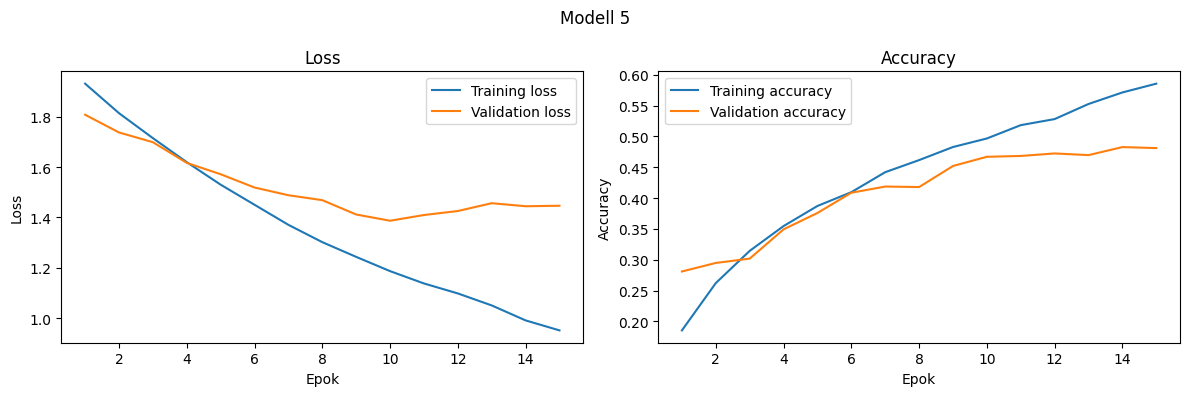

In [37]:
plot_history(history_5, title="Modell 5")

In [38]:
evaluate_per_class(model_5, X_val_m2_scaled, y_val_m2)

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Känsla,Antal bilder (support),Rätt gissade,Accuracy
0,Fear,600,132,22.00%
1,Surprise,600,245,40.83%
2,Angry,600,250,41.67%
3,Sad,600,261,43.50%
4,Disgust,88,39,44.32%
5,Happy,600,372,62.00%
6,Neutral,600,423,70.50%


Med hjälp av class_weight="balanced" så ökar träffsäkerheten för disgust till ca 52%.

### 3.6 Modell 6 - new data who dis

Offline data augmentation betyder att man skapar de modifierade bilderna innan träningen börjar och sparar dem som nya filer. Till exempel kan man ta en orginalbild och skapa flera nya versioner med rotation, beskärning, ändrad ljusstyrka elle brus. Dessa sparas sedan på disk och används som en större träningsmängd. 

Skillnaden mot online data augmentation är att online augmentation sker under själva träningen. Då skapas nya variationer dynamiskt varje gång modellen tränar på en batch. Modellen kan alltså se lite olika versioner av samma bild i olika epoker. Det kräver mindre lagringsutrymme, men mer beräkning under träningen. 

En nackdel med offline augmentation är att modellen ser samma förskapade bilder om och om igen, vilket kan ge mindre variation än onine augmentation. Fördelen är att träningen kan gå snabbare eftersom augmentationen redan är gjord i förväg. 

Jag kommer använda mig av offline data augmentation. 

Först isoleras alla bilder i klassen disgust, eftersom den klassen har färre exempel än de andra. Därefter beräknas hur många nya bilder som behöver skapas för att klassen ska nå målet på 2400 bilder. Varje ny bild skapas genom att en befinlig disgust-bild väljs och skickas genom en "augmenterings-pipeline" som är anpassad för ansikten och FER-2013 (de augmenterade bilderna ska alltså se ut ungefär på samma sätt som de bilder som redan finns i datasetet). De augmenterade bilderna sparas sedan i listor och omvandlas till Numpy-Arrayer som till sist slås ihop med den ursprungliga träningsdatan. 

Bilderna sparas alltså inte som separata filer på datorn, utan som nya arrayer i träningsdatasetet innan modellen tränas. Det räknas ändå som offline augmentation eftersom augmenteringen görs i förväg innan själva träningen startar, och den utökade träningsmängden används sedan som ett färdigt dataset.

In [32]:
# Isolerar alla existerande Disgust-bilder (Klass 1) från träningsdatan
disgust_indices = np.where(y_train_m2 == 1)[0]
X_disgust = X_train_m2_scaled[disgust_indices]
y_disgust = y_train_m2[disgust_indices]

# Räknar ut exakt hur många extra bilder som behöver skapas
target_count = 2400
current_count = len(disgust_indices)
needed_count = target_count - current_count

print(f"Hittade {current_count} originalbilder av Disgust.")
print(f"Genererar {needed_count} nya bilder för att nå {target_count}...")

# Definierar en "augmenterings-pipeline" (Anpassad för ansikten)
data_augmentation_seq = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),                    # Speglar ansiktet horisontellt
    layers.RandomRotation(0.05, fill_mode="nearest"),   # Roterar lite (max ~18 grader)
    layers.RandomZoom(0.1),                             # Zoomar in/ut lite
    layers.RandomTranslation(0.05, 0.05)                # flyttar bilden lite i höjd- och sidled
])

augmented_images = []
augmented_labels = []

# Genererar bilderna genom att loopa över originalbilderna
for i in range(needed_count):
    # Väljer en slumpmässig Disgust-bild
    base_img = X_disgust[i % current_count]
    
    # Kör augmenteringen
    aug_img = data_augmentation_seq(np.expand_dims(base_img, axis=0), training=True)
    
    augmented_images.append(np.squeeze(aug_img, axis=0))
    augmented_labels.append(1) 

# Omvandlar de nya bilderna till numpy-arrayer
X_disgust_aug = np.array(augmented_images)
y_disgust_aug = np.array(augmented_labels)

# Slår ihop originaldatan med den helt nya augmenterade datan
X_train_augmented = np.concatenate([X_train_m2_scaled, X_disgust_aug], axis=0)
y_train_augmented = np.concatenate([y_train_m2, y_disgust_aug], axis=0)

# Verifierar att det blev rätt
print("\nNy klassfördelning i X_train_augmented")
for idx, label in enumerate(["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]):
    print(f"Klass {idx} ({label}): {np.bincount(y_train_augmented)[idx]} bilder")

Hittade 348 originalbilder av Disgust.
Genererar 2052 nya bilder för att nå 2400...

Ny klassfördelning i X_train_augmented
Klass 0 (angry): 2400 bilder
Klass 1 (disgust): 2400 bilder
Klass 2 (fear): 2400 bilder
Klass 3 (happy): 2400 bilder
Klass 4 (neutral): 2400 bilder
Klass 5 (sad): 2400 bilder
Klass 6 (surprise): 2400 bilder


In [33]:
model_6 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [34]:
compile_model(model_6, lr=0.001)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential_1, built=True>

In [35]:
history_6, training_time_6 = train_model(
    model_6, X_train_augmented, y_train_augmented, X_val_m2_scaled, y_val_m2,
    title="Modell 6",
    patience=5
)

Startar träning av Modell 6
Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3014 - loss: 1.7415 - val_accuracy: 0.3557 - val_loss: 1.6704
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4245 - loss: 1.4995 - val_accuracy: 0.4029 - val_loss: 1.5890
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4603 - loss: 1.4041 - val_accuracy: 0.4184 - val_loss: 1.5497
Epoch 4/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4855 - loss: 1.3528 - val_accuracy: 0.4355 - val_loss: 1.4715
Epoch 5/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5124 - loss: 1.2758 - val_accuracy: 0.4344 - val_loss: 1.4612
Epoch 6/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5391 - loss: 1.2128 - val_accuracy: 0.4585 - val_loss: 1.4209
Epoch 7/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5604 - loss: 1.1631 - val_accuracy: 0.4786 - val_loss: 1.3753
Epoch 8/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.58

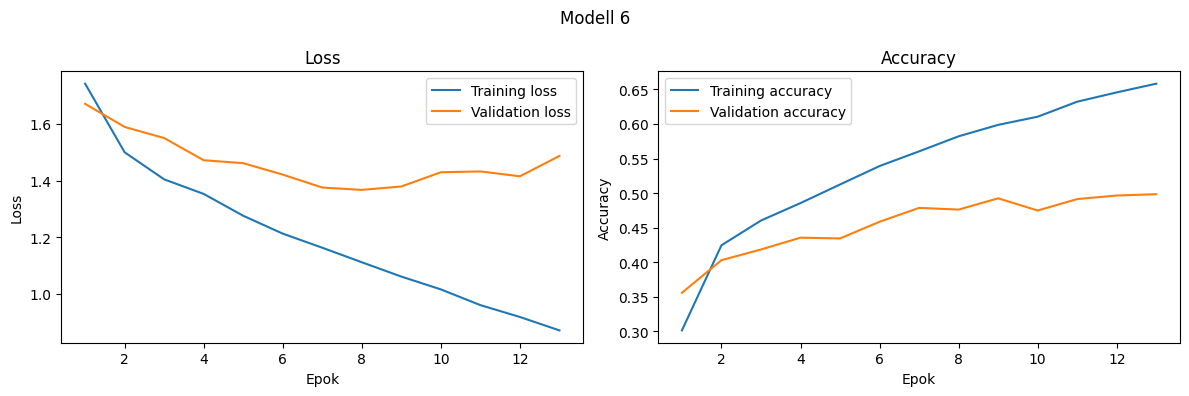

In [36]:
plot_history(history_6, title="Modell 6")

In [37]:
evaluate_per_class(model_6, X_val_m2_scaled, y_val_m2)

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Känsla,Antal bilder (support),Rätt gissade,Accuracy
0,Disgust,88,8,9.09%
1,Fear,600,171,28.50%
2,Sad,600,223,37.17%
3,Surprise,600,261,43.50%
4,Angry,600,269,44.83%
5,Neutral,600,411,68.50%
6,Happy,600,413,68.83%


I den här modellen som har fått tillgång till fler disgust-bilder så ökar träffsäkerheten för den klassen endast till 11%.

### Sammanställning Skillnad mellan class_weights = balanced och offline data augumentation

In [ ]:
# Hämtar rådatan
df_m4 = evaluate_per_class(model_4_1, X_val_m2_scaled, y_val_m2).data
df_m5 = evaluate_per_class(model_5, X_val_m2_scaled, y_val_m2).data
df_m6 = evaluate_per_class(model_6, X_val_m2_scaled, y_val_m2).data

# Skapar grunden för den nya tabellen med klassnamn och antal bilder
df_sammanstalld = df_m4[["Känsla", "Antal bilder (support)"]].copy()

# Lägger till träffsäkerheten från resp. modell
df_sammanstalld["Modell 4.1 (Baseline)"] = df_m4["Accuracy"]
df_sammanstalld["Modell 5 (Class Weights)"] = df_m5["Accuracy"]
df_sammanstalld["Modell 6 (Data Augmentation)"] = df_m6["Accuracy"]

# Sorterar tabellen efter antal bilder så att "Disgust" hamnar överst
df_sammanstalld = df_sammanstalld.sort_values(
    by="Antal bilder (support)", ascending=True
).reset_index(drop=True)

# Formaterar alla tre modellkolumner som procent
df_sammanstalld.style.format(
    {
        "Modell 4.1 (Baseline)": "{:.2%}",
        "Modell 5 (Class Weights)": "{:.2%}",
        "Modell 6 (Data Augmentation)": "{:.2%}",
    }
)

Den modell som fick högst accuracy på disgust-klassen är Modell 5, som hade rätt på över 22% av alla disgust-bilderna. 

Alla tre modellerna fick liknande resultat för de tre klasser som var lättast (neutral, happy och angry). 

Modell 6 var sämst på de tre klasser som var svårast (disgust, fear och sad). Eller ja, Modell 6 gav visserligen ett lite bättre resultat på disgust jämfört med baseline, men sänkte modellen på de flesta övriga klasser. 

En trolig anledning till att Modell 5 fungerade bättre än Modell 6 är att FER-2013 redan är ett brusigt dataset med låg upplösning. När dessa redan otydliga bilder manipulras riskerar de subtila pixelmönstren som definierr känslouttrycken att förstöras. Detta introducerade troligtvis mer brus än användbar information, vilket förvirrade modellen under träningen.

## 4. Utvärdering

Det finns inte tid eller ork till att testa hur samtliga modeller presterar på testdatan. 

Därför behöver jag ha en sammanställande tabell över alla modeller där validation accuracy, validation accuracy och träningstid framgår.

In [38]:
def get_model_stats(model_name, history_obj, total_time_sec=None, early_stopping=True):
    """Plockar ut data för en modell.
    Om early_stopping=True väljs epoken med lägst val_loss.
    Om early_stopping=False väljs den allra sista epoken.
    """
    h = history_obj.history

    if early_stopping:
        chosen_idx = np.argmin(h["val_loss"])
        epok_text = "Bästa epok"
    else:
        chosen_idx = len(h["val_loss"]) - 1
        epok_text = "Sista epok"
        
    chosen_epoch = chosen_idx + 1

    if total_time_sec is not None:
        cumulative_time = (total_time_sec / len(h["val_loss"])) * chosen_epoch
        minutes = int(cumulative_time // 60)
        sec = int(cumulative_time % 60)
        tid_str = f"{minutes}m {sec}s"
    else:
        tid_str = "Ej mätt"

    return {
        "Modell": f"{model_name} ({epok_text} {chosen_epoch})",
        "Val Loss": round(h["val_loss"][chosen_idx], 4),
        "Val Accuracy": f"{h['val_accuracy'][chosen_idx] * 100:.2f}%",
        "Träningstid (ackumulerad)": tid_str,
        "Training Loss": round(h["loss"][chosen_idx], 4),
        "Training Accuracy": f"{h['accuracy'][chosen_idx] * 100:.2f}%",
    }

In [ ]:
table_data_master = []

# MODELL 1
table_data_master.append(get_model_stats("Modell 1.1 Baseline", history_1_1, early_stopping=False))
table_data_master.append(get_model_stats("Modell 1.2 Förbättrad", history_1_2, early_stopping=False))
table_data_master.append(get_model_stats("Modell 1.3 Slutlig Binär", history_1_3, early_stopping=False))

# MODELL 2 & 3 
table_data_master.append(get_model_stats("Modell 2.1 Feature Extraction", history_2_1, training_time_2_1, early_stopping=False))
table_data_master.append(get_model_stats("Modell 2.2 Partial Fine-tuning", history_2_2, training_time_2_2, early_stopping=False))
table_data_master.append(get_model_stats("Modell 2.3 Full Fine-tuning", history_2_3, training_time_2_3, early_stopping=False))
table_data_master.append(get_model_stats("Modell 3 Kontroll (45 epoker)", history_3, training_time_3, early_stopping=False))
table_data_master.append(get_model_stats("Modell 3 Kontroll (45 epoker)", history_3, training_time_3))

# MODELL 4
table_data_master.append(get_model_stats("Modell 4.1 Baseline", history_4_1, training_time_4_1))
table_data_master.append(get_model_stats("Modell 4.2 BatchNormalization", history_4_2, training_time_4_2))
table_data_master.append(get_model_stats("Modell 4.3 Större nätverk", history_4_3, training_time_4_3))
table_data_master.append(get_model_stats("Modell 4.4 GlobalAveragePooling2D", history_4_4, training_time_4_4))
table_data_master.append(get_model_stats("Modell 4.5 Baseline + GlobalAveragePooling2D", history_4_5, training_time_4_5))
table_data_master.append(get_model_stats("Modell 4.6 Längre träningstid", history_4_6, training_time_4_6))

# MODELL 5 & 6
table_data_master.append(get_model_stats("Modell 5 Class Weights", history_5, training_time_5))
table_data_master.append(get_model_stats("Modell 6 Data Augmentation", history_6, training_time_6))

# Bygg och visa tabellen
df_master = pd.DataFrame(table_data_master)
df_master

### Modell 1.3 och testdata

In [ ]:
probs_1_3 = model_1_3.predict(X_test_m1_scaled)
pred_1_3 = np.argmax(probs_1_3, axis=1)

test_acc = accuracy_score(y_test_m1, pred_1_3)
test_f1 = f1_score(y_test_m1, pred_1_3, average="binary")
val_acc = history_1_3.history["val_accuracy"][-1]

labels_2 = ["Happy", "Sad"]

random_acc = 1 / len(labels_2)

print("\nResultat på testdata för Modell 1.3 (binär)\n")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test F1-score: {test_f1:.4f}\n")
print(f"Validation Accuracy: {val_acc * 100:.2f}%\n")
print(f"Slumpen: {random_acc * 100:.2f}%")

In [ ]:
confidences = np.max(probs_1_3, axis=1)

correct_mask = y_test_m1 == pred_1_3
correct_indices = np.where(correct_mask)[0]

best_correct_idx = correct_indices[np.argmax(confidences[correct_mask])]

incorrect_mask = y_test_m1 != pred_1_3
incorrect_indices = np.where(incorrect_mask)[0]

worst_incorrect_idx = incorrect_indices[np.argmax(confidences[incorrect_mask])]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

true_label_correct = labels_2[y_test_m1[best_correct_idx]]
axes[0].imshow(X_test_m1_scaled[best_correct_idx].squeeze(), cmap="gray")
axes[0].set_title(
    f"Mest säker RÄTT\nSann känsla: {true_label_correct}\nKonfidens: {confidences[best_correct_idx]*100:.1f}%",
    color="green",
    fontsize=12,
)
axes[0].axis("off")

true_label_incorrect = labels_2[y_test_m1[worst_incorrect_idx]]
guessed_label_incorrect = labels_2[pred_1_3[worst_incorrect_idx]]
axes[1].imshow(X_test_m1_scaled[worst_incorrect_idx].squeeze(), cmap="gray")
axes[1].set_title(
    f"Mest säker FEL\nSann: {true_label_incorrect} | Gissad: {guessed_label_incorrect}\nKonfidens på fel gissning: {confidences[worst_incorrect_idx]*100:.1f}%",
    color="red",
    fontsize=12,
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Modell 4.4 och testdata

In [39]:
probs_6 = model_6.predict(X_test_m2_scaled)
pred_6 = np.argmax(probs_6, axis=1)

test_acc = accuracy_score(y_test_m2, pred_6)
test_f1 = f1_score(y_test_m2, pred_6, average="macro")

best_idx_m41 = np.argmin(history_6.history["val_loss"])
val_acc = history_6.history["val_accuracy"][best_idx_m41]

labels_7 = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

random_acc = 1 / len(labels_7)

print("\nResultat på testdata för Modell 6 (alla klasser)\n")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test F1-score: {test_f1:.4f}\n")
print(f"Validation Accuracy: {val_acc * 100:.2f}%\n")
print(f"Slumpen: {random_acc * 100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Resultat på testdata för Modell 6 (alla klasser)

Test Accuracy: 49.43%
Test F1-score: 0.4490

Validation Accuracy: 47.61%

Slumpen: 14.29%


In [40]:
wrong_mask = y_test_m2 != pred_6

wrong_true = [labels_7[i] for i in y_test_m2[wrong_mask]]
wrong_guessed = [labels_7[i] for i in pred_6[wrong_mask]]

df_wrong = pd.DataFrame({"Sann känsla": wrong_true, "Gissad som": wrong_guessed})
top_3_wrong = df_wrong.value_counts().head(3).reset_index(name="Antal fel")

print("Topp 3 vanligaste förväxlingarna\n")
print(top_3_wrong.to_string(index=False))

Topp 3 vanligaste förväxlingarna

Sann känsla Gissad som  Antal fel
        Sad   Surprise        264
   Surprise      Angry        252
       Fear   Surprise        248


In [41]:
true_class_name_all = [labels_7[i] for i in y_test_m2]
guessed_class_name_all = [labels_7[i] for i in pred_6]

df_totalt = pd.DataFrame({"Facit": true_class_name_all, "Modellens Gissningar": guessed_class_name_all})

facit_counts = df_totalt["Facit"].value_counts()
gissat_counts = df_totalt["Modellens Gissningar"].value_counts()

df_num_guesses = pd.DataFrame({
    "Antal i Testdata (Facit)": facit_counts,
    "Modellens totala gissningar": gissat_counts
})

df_num_guesses = df_num_guesses.sort_values(by="Modellens totala gissningar", ascending=False)

df_num_guesses.index.name = None

print("Jämförelse: Facit vs Modellens gissningar\n")
print(df_num_guesses)

Jämförelse: Facit vs Modellens gissningar

          Antal i Testdata (Facit)  Modellens totala gissningar
Happy                         1774                         1601
Surprise                      1247                         1408
Angry                          958                         1389
Sad                           1233                         1012
Fear                          1024                          875
Neutral                        831                          830
Disgust                        111                           63


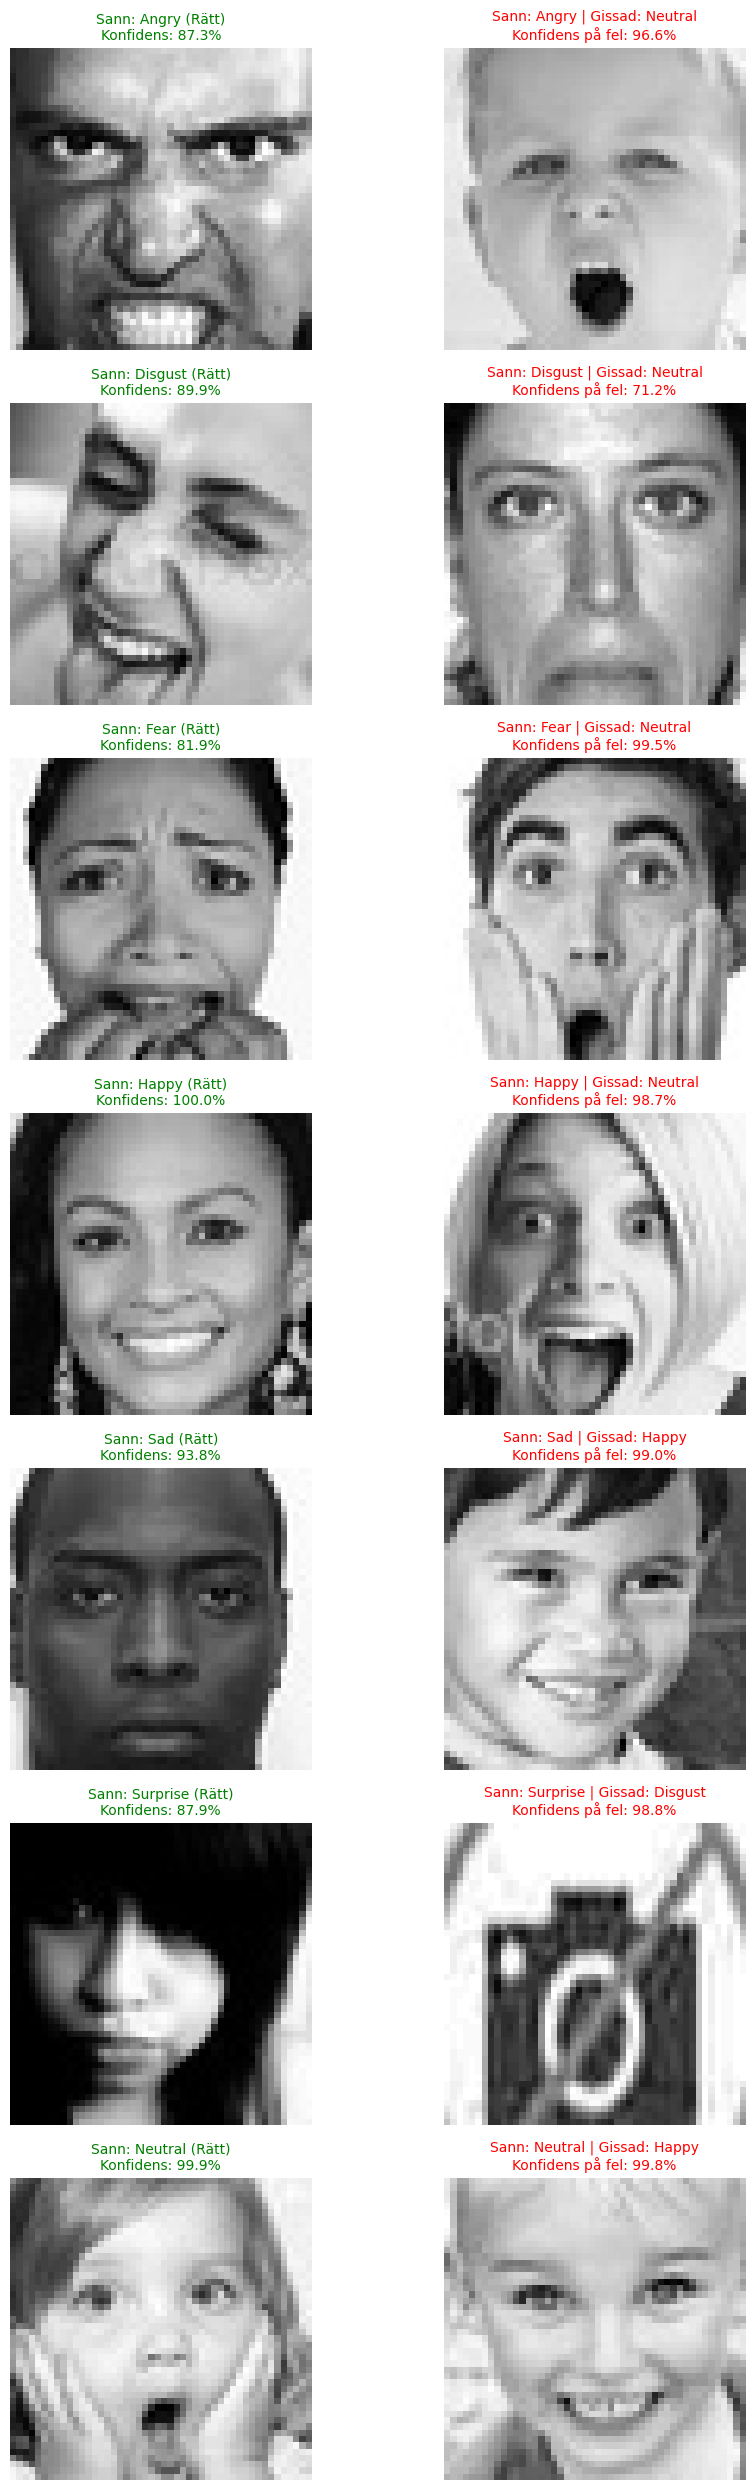

In [42]:
confidences = np.max(probs_6, axis=1)

fig, axes = plt.subplots(7, 2, figsize=(10, 25))

for i, label in enumerate(labels_7):
    mask_true = y_test_m2 == i

    r_mask = mask_true & (pred_6 == i)
    if np.sum(r_mask) > 0:
        r_indices = np.where(r_mask)[0]
        best_correct_idx = r_indices[np.argmax(confidences[r_mask])]

        axes[i, 0].imshow(X_test_m2_scaled[best_correct_idx].squeeze(), cmap="gray")
        axes[i, 0].set_title(
            f"Sann: {label} (Rätt)\nKonfidens: {confidences[best_correct_idx]*100:.1f}%",
            color="green",
            fontsize=10,
        )
    else:
        axes[i, 0].text(
            0.5, 0.5, "Inga rätt", ha="center", va="center", fontsize=12
        )
    axes[i, 0].axis("off")

    f_mask = mask_true & (pred_6 != i)
    if np.sum(f_mask) > 0:
        f_indices = np.where(f_mask)[0]
        worst_incorrect_idx = f_indices[np.argmax(confidences[f_mask])]

        guessed_label = labels_7[pred_6[worst_incorrect_idx]]
        axes[i, 1].imshow(
            X_test_m2[worst_incorrect_idx].squeeze(), cmap="gray"
        )
        axes[i, 1].set_title(
            f"Sann: {label} | Gissad: {guessed_label}\nKonfidens på fel: {confidences[worst_incorrect_idx]*100:.1f}%",
            color="red",
            fontsize=10,
        )
    else:
        axes[i, 1].text(
            0.5, 0.5, "Inga fel", ha="center", va="center", fontsize=12
        )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 5. Prediktioner på ny data

In [ ]:
model_4_1.save("best_model.keras")

In [ ]:
emotion_detector = tf.keras.models.load_model("best_model.keras")

In [ ]:
def resting_batch_face(model, image_path):
    """
    Ett "program" där användaren kan läsa in en bild och låta en vald 
    emotion detector-modell säga vilken ansiktsuttryck personen på bilden har.
    """
    emotions = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

    img_original = tf.keras.utils.load_img(image_path)
    img_processed = tf.keras.utils.load_img(image_path, target_size=(48, 48), color_mode="grayscale")

    img_array = tf.keras.utils.img_to_array(img_processed)
    img_ready = np.expand_dims(img_array / 255.0, axis=0)

    probs = model.predict(img_ready, verbose=0)
    pred_idx = np.argmax(probs, axis=1)[0]
    konfidence = probs[0][pred_idx] * 100
    guessed_emotion = emotions[pred_idx]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_original)
    axes[0].set_title("Originalbild (Före preprocessing)", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(img_array.squeeze(), cmap="gray")
    axes[1].set_title(
        f"Modellens indata (48x48)\nGissning: {guessed_emotion} ({konfidence:.1f}%)",
        fontsize=11,
        fontweight="bold",
        color="green" if guessed_emotion in ["Happy", "Surprise"] else "blue",
    )
    axes[1].axis("off")

    plt.suptitle(f"Resultat för: {image_path}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
resting_batch_face(emotion_detector, "demo_images/demo_img1.jpg")

In [ ]:
resting_batch_face(emotion_detector, "demo_images/demo_img2.jpg")

## 6. Analys av resultatet

## 7. Reflektion